# Echo State Networks hyperparameter and reservoir topology study I - on ERA5 dataset

**Notebook 1** of a research series on Reservoir Computing (ESN) studying their reservoir topology and architecture.

| | |
|---|---|
| **Author** | *Antonio Macías Ferrera* |
| **Affiliation** | *University of Seville* |
| **Date** | feb 2026 |

---


## Abstract

This is the first notebook on a seires of experiments framed into Antonio Macías Ferrera's final thesis of the Master's defree on Logic, Computer Science and Artificial Intelligence of the University of Seville called **General Study of the reservoir topology on Echo State Networks**.  

In this notebook we will address a systematic investigation for short-term hourly temperature forecasting using a ERA5 reanalysis dataset from the Copernicus Climate Data Store. The study is structured in two phases.

**Phase A** performs a randomised **hyperparameter search** over **reservoir size**, **spectral radius**, **leak rate**, **input scaling**, **connectivity**, **ridge regularisation**, and **washout length**. Each configuration is evaluated under strict 10-fold temporal cross-validation to preclude data leakage. Feature selection via mutual information is carried out independently within each fold, using training data only.

**Phase B** fixes the best-performing hyperparameters from Phase A and **compares three reservoir graph topologies** - Erdős-Rényi (**random**), Watts-Strogatz (**small-world**), and Barabási-Albert (**scale-free**) - by constructing custom weight matrices, rescaling them to the desired spectral radius, and repeating the temporal cross-validation protocol.

All results are analysed with descriptive statistics and Seaborn visualisations suitable for inclusion in an academic thesis.

---


## Table of Contents

1. [Environment Setup](#1-environment-setup)
2. [Data Download and Preprocessing](#2-data-download-and-preprocessing)
3. [Exploratory Data Analysis](#3-exploratory-data-analysis)
   - 3.1. Feature analysis (t2m)
4. [Echo State Network Methodology](#4-echo-state-network-methodology)
5. [Phase A — Hyperparameter Study](#5-phase-a--hyperparameter-study)
   - 5.1. Grid search & results summary
   - 5.2. Hyperparameter Single Hyperparameter Study (OAT): N · sr · lr · ridge · washout
   - 5.3. Refined grid search (anchored on SHS findings)
   - 5.4. Best-model prediction on the ERA5 temperature series
6. [Phase B — Reservoir Topology Study](#6-phase-b--reservoir-topology-study)
   - 6.1. Erdős-Rényi: Single Hyperparameter Study on edge probability p
   - 6.2. Watts-Strogatz: Single Hyperparameter Study on ring neighbours k and rewiring p_rewire
     - 6.2a. Joint heatmap on k x p_rewire
     - 6.2b. Best combinations from the WS heatmap
     - 6.2c. Selected WS pair for downstream comparison
   - 6.3. Barabási-Albert: Single Hyperparameter Study on edges-per-node m
   - 6.4. Cross-topology comparison and Phase B conclusions
7. [Conclusions](#7-conclusions)

## 1. Environment Setup

The following cell installs all required packages in the **active local Jupyter kernel**.

Recommended workflow for local execution in VS Code:
1. Create/select `.venv` as the Python interpreter.
2. Select the notebook kernel linked to `.venv`.
3. Install the following dependencies on the `.venv`::
   - xarray
   - reservoirpy
   - scikit-learn
   - pandas
   - numpy
   - matplotlib
   - seaborn
   - networkx
   - scipy

In [ ]:
# ---------------------------------------------------------------------------
# Standard library
# ---------------------------------------------------------------------------
import os
import time
import warnings
import hashlib
import math
from pathlib import Path
from datetime import datetime

# ---------------------------------------------------------------------------
# Scientific computing
# ---------------------------------------------------------------------------
import numpy as np
import pandas as pd
import xarray as xr
from scipy import stats

# ---------------------------------------------------------------------------
# Visualisation
# ---------------------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------------------------
# Machine learning utilities
# ---------------------------------------------------------------------------
from sklearn.model_selection import TimeSeriesSplit, ParameterGrid
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# ---------------------------------------------------------------------------
# Graph generation
# ---------------------------------------------------------------------------
import networkx as nx

# ---------------------------------------------------------------------------
# Reservoir computing
# ---------------------------------------------------------------------------
import reservoirpy as rpy
from reservoirpy.nodes import Reservoir, Ridge

# ---------------------------------------------------------------------------
# Environment
# ---------------------------------------------------------------------------
warnings.filterwarnings("ignore")

print("Library versions")
print("----------------")
for lib_name, lib in [("numpy", np), ("pandas", pd), ("xarray", xr),
                       ("reservoirpy", rpy), ("networkx", nx)]:
    print(f"  {lib_name:15s} {lib.__version__}")
print(f"  {'seaborn':15s} {sns.__version__}")

Library versions
----------------
  numpy           2.4.2
  pandas          3.0.1
  xarray          2026.2.0
  reservoirpy     0.4.1
  networkx        3.6.1
  seaborn         0.13.2


In [2]:
# ---------------------------------------------------------------------------
# Global configuration
# ---------------------------------------------------------------------------

ACTIVE_CITY = "Seville"

# ERA5 variable used (single-variable setup: t2m only)
VAR_LABELS = {
    "t2m": "2 m temperature (°C)",
}

# Experiment controls
LAG      = 10   # number of lagged input timesteps
N_SPLITS = 10   # temporal CV folds

# Filled dynamically after preprocessing
YEARS = []

print("Configuration loaded.")
print(f"  City      : {ACTIVE_CITY}")
print(f"  Variable  : t2m (2 m temperature, °C) — univariate setup")
print(f"  Lag       : {LAG} timesteps")
print(f"  CV folds  : {N_SPLITS}")

Configuration loaded.
  City      : Seville
  Variable  : t2m (2 m temperature, °C) — univariate setup
  Lag       : 10 timesteps
  CV folds  : 10



<br>

---

## 2. Data download and preproccessing

### Data Source

We use the **ERA5 hourly data on single levels** product from the [Copernicus Climate Data Store (CDS)](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels?tab=overview). ERA5 is the fifth-generation ECMWF atmospheric reanalysis, providing hourly estimates of atmospheric, land, and oceanic variables on a regular 0.25° x 0.25° latitude-longitude grid from 1940 to the present (Hersbach et al., 2020).

### Variable Justification

| Variable | Rationale |
|----------|-----------|
| `2m_temperature` | Direct measurement of near-surface air temperature; the target variable. |
| `surface_pressure` | Reflects synoptic-scale weather patterns (e.g., anticyclones bring clear skies and temperature extremes). |
| `mean_sea_level_pressure` | Complements surface pressure by removing altitude effects; useful for detecting large-scale circulation changes. |
| `total_cloud_cover` | Modulates incoming solar radiation and outgoing long-wave radiation, directly affecting surface temperature. |
| `10m_u_component_of_wind` | Zonal wind component. |
| `10m_v_component_of_wind` | Meridional wind component; together with u-wind captures **wind speed and direction**. |

**Why will we use 2 m temperature as the target variable for city-level forecasting?**
The 2 m temperature is the standard measurement height, making ERA5's `t2m` directly comparable to weather station observations. For a city like Seville,  `t2m` is the variable most relevant for energy demand, public health (heat waves), and urban planning applications.


In [3]:
# ---------------------------------------------------------------------------
# Use downloaded ERA5 file
# ---------------------------------------------------------------------------
manual_candidates = [
    Path("data.grib"),
    Path("dadbcc0234dcab4f0d572213991ebcf8.nc"),
]

nc_path = next((p for p in manual_candidates if p.exists()), None)

if nc_path is None:
    raise FileNotFoundError(
        "Manual file not found. Expected one of: data.grib or dadbcc0234dcab4f0d572213991ebcf8.nc "
        "in the current folder."
    )

print("[INFO] Using manually downloaded ERA5 file.")
print(f"\n{'='*60}")
print(f"  Data file   : {nc_path.resolve()}")
print(f"  File format : {nc_path.suffix.lower().lstrip('.')} ")
print(f"{'='*60}")


[INFO] Using manually downloaded ERA5 file.

  Data file   : /Users/antoniommff/Developer/2_fase_experimentacion/data.grib
  File format : grib 



<br>

<br>

The raw ERA5 NetCDF file may contain a small spatial grid (the bounding box around the
city). We perform a **spatial average** over the grid cells to obtain a single representative
time series per variable. Temperature is converted from **Kelvin to Celsius**. The result is
a chronologically sorted `pandas.DataFrame` indexed by time.

### Missing-value strategy

ERA5 reanalysis data is generally complete. However, we:
1. Check for any `NaN` values after spatial averaging.
2. If gaps exist and are short (≤ 3 consecutive hours), fill by linear interpolation.
3. If longer gaps exist, drop the affected rows and document the amount of data lost.


In [ ]:
# ---------------------------------------------------------------------------
# Load ERA5 dataset (NetCDF or GRIB) with xarray
# ---------------------------------------------------------------------------
def open_era5_dataset(path: Path) -> xr.Dataset:
    suffix = path.suffix.lower()

    if suffix == ".nc":
        return xr.open_dataset(path)

    if suffix in {".grib", ".grb"}:
        try:
            return xr.open_dataset(path, engine="cfgrib")
        except Exception:
            import cfgrib
            ds_list = cfgrib.open_datasets(str(path))
            if len(ds_list) == 0:
                raise ValueError(f"No readable GRIB datasets found in {path}.")
            if len(ds_list) == 1:
                return ds_list[0]
            return xr.merge(ds_list, compat="override", combine_attrs="drop_conflicts")

    raise ValueError(f"Unsupported file extension: {suffix}")

ds = open_era5_dataset(nc_path)
print("Dataset variables:", list(ds.data_vars))
print("Dimensions:       ", dict(ds.dims))
print()

# ---------------------------------------------------------------------------
# Spatial average over the bounding box
# ---------------------------------------------------------------------------
# The spatial dimensions may be named 'latitude'/'longitude' or 'lat'/'lon'.
lat_dim = "latitude" if "latitude" in ds.dims else ("lat" if "lat" in ds.dims else None)
lon_dim = "longitude" if "longitude" in ds.dims else ("lon" if "lon" in ds.dims else None)

if lat_dim is not None and lon_dim is not None:
    ds_mean = ds.mean(dim=[lat_dim, lon_dim])
else:
    ds_mean = ds
    print("[INFO] No lat/lon dimensions found. Using dataset as-is.")

# ---------------------------------------------------------------------------
# Build a pandas DataFrame
# ---------------------------------------------------------------------------
# Determine the time dimension name
if "valid_time" in ds_mean.coords or "valid_time" in ds_mean.dims:
    time_dim = "valid_time"
elif "time" in ds_mean.coords or "time" in ds_mean.dims:
    time_dim = "time"
else:
    raise ValueError("No time coordinate found (expected 'time' or 'valid_time').")

# Extract only t2m (univariate setup)
if "t2m" not in ds_mean.data_vars:
    available = list(ds_mean.data_vars)
    raise ValueError(f"Variable 't2m' not found in dataset. Available: {available}")

data = {"t2m": ds_mean["t2m"].values}

df = pd.DataFrame(data, index=pd.DatetimeIndex(ds_mean[time_dim].values, name="time"))

# ---------------------------------------------------------------------------
# Convert temperature from Kelvin to Celsius
# ---------------------------------------------------------------------------
if "t2m" in df.columns:
    df["t2m"] = df["t2m"] - 273.15

# Sort chronologically (safety measure)
df = df.sort_index()

# Capture years dynamically for downstream plot titles
YEARS = sorted(df.index.year.unique().tolist())

# ---------------------------------------------------------------------------
# Missing-value handling
# ---------------------------------------------------------------------------
n_missing_before = df.isna().sum().sum()
print(f"Missing values before treatment: {n_missing_before}")

if n_missing_before > 0:
    # Interpolate short gaps (up to 3 hours)
    df = df.interpolate(method="time", limit=3)
    n_missing_after = df.isna().sum().sum()
    if n_missing_after > 0:
        rows_before = len(df)
        df = df.dropna()
        print(f"Dropped {rows_before - len(df)} rows with remaining NaN values.")
    else:
        print("All short gaps filled by linear interpolation.")
else:
    print("No missing values detected.")

print(f"\nFinal DataFrame shape: {df.shape}")
print(f"Period: {df.index.min()} -> {df.index.max()}")
print(f"Frequency: {pd.infer_freq(df.index[:100])}")
print(f"Years available: {YEARS[0]}-{YEARS[-1]} ({len(YEARS)} years)")
df.head()

Dataset variables: ['u10', 'v10', 't2m', 'msl', 'sp', 'tcc']
Dimensions:        {'time': 16128, 'latitude': 2, 'longitude': 2}

Missing values before treatment: 0
No missing values detected.

Final DataFrame shape: (16128, 1)
Period: 2022-01-01 00:00:00 → 2025-12-28 22:00:00
Frequency: 2h
Years available: 2022-2025 (4 years)


,t2m
time,
2022-01-01 00:00:00,10.712189
2022-01-01 02:00:00,9.573273
2022-01-01 04:00:00,9.002655
2022-01-01 06:00:00,8.383057
2022-01-01 08:00:00,8.273407


In [5]:
# ---------------------------------------------------------------------------
# Summary statistics
# ---------------------------------------------------------------------------
summary = df.describe().T
summary["unit"] = [VAR_LABELS.get(c, "") for c in summary.index]
print("Summary statistics of the preprocessed dataset:\n")
summary


Summary statistics of the preprocessed dataset:



,count,mean,std,min,25%,50%,75%,max,unit
t2m,16128.0,19.378155,7.629502,-0.193817,13.741661,18.742706,24.526451,41.809387,2 m temperature (°C)



<br>

---

## 3. Exploratory Data Analysis


<br>

### 3.1. Feature analysis

We visualise the temporal structure, distributions, and seasonal patterns of each variable
to inform modelling decisions.


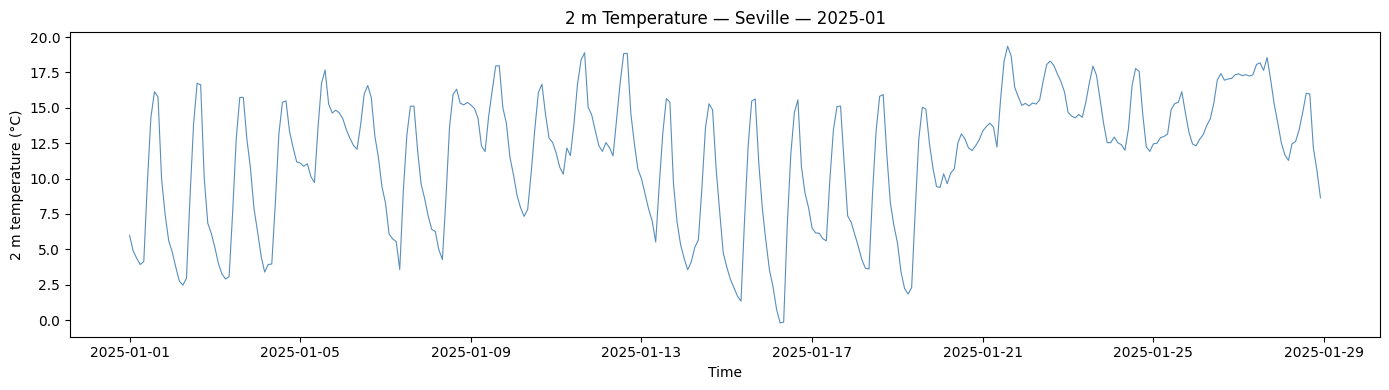

In [6]:
# ---------------------------------------------------------------------------
# Full time series for t2m — selected month
# ---------------------------------------------------------------------------
YEAR_TO_PLOT  = 2025
MONTH_TO_PLOT = 1  # January

df_month = df[(df.index.year == YEAR_TO_PLOT) & (df.index.month == MONTH_TO_PLOT)]

if df_month.empty:
    print(f"No data available for {YEAR_TO_PLOT}-{MONTH_TO_PLOT:02d}.")
else:
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(df_month.index, df_month["t2m"], linewidth=0.8, color="steelblue", alpha=0.9)
    ax.set_ylabel(VAR_LABELS["t2m"])
    ax.set_xlabel("Time")
    ax.set_title(f"2 m Temperature — {ACTIVE_CITY} — {YEAR_TO_PLOT}-{MONTH_TO_PLOT:02d}")
    fig.tight_layout()
    plt.show()

This graph represents the full time series of hourly variables for a specific month and year (January 2025). Here's what it shows:

- **X-Axis (Time)**: Represents the **time** (in hours) for the selected month and year (January 2025).
- **Y-Axis (Variable Values)**: Displays the values of each hourly variables (temperature, wind speed) for the selected city (Seville).
- **Each subplots**: Corresponds to a different variable, with its respective label on the Y-axis.

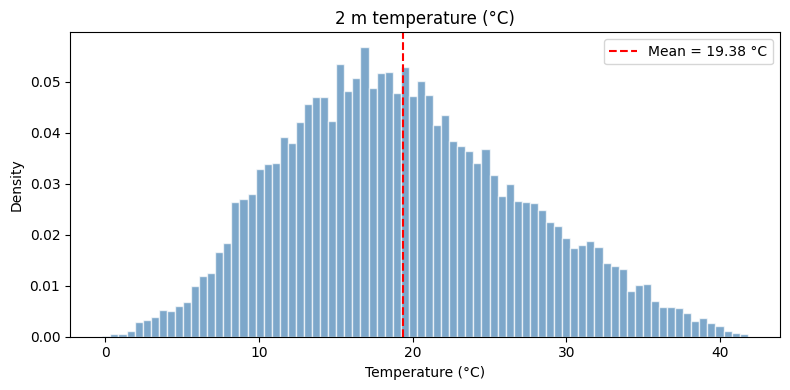

count    16128.000
mean        19.378
std          7.630
min         -0.194
25%         13.742
50%         18.743
75%         24.526
max         41.809
Name: t2m, dtype: float64


In [7]:
# ---------------------------------------------------------------------------
# Distribution of t2m
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df["t2m"].values, bins=80, density=True, alpha=0.7, color="steelblue", edgecolor="white")
ax.axvline(df["t2m"].mean(), color="red", linestyle="--", linewidth=1.5,
           label=f"Mean = {df['t2m'].mean():.2f} °C")
ax.set_title(VAR_LABELS["t2m"])
ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.show()
print(df["t2m"].describe().round(3))

This graph represents the marginal distributions of each of the ERA5 variables for the selected city

- Each histogram: Corresponds to a specific variable, showing its distribution as a histogram.
- **X-Axis (Variable Values)**: Represents the range of values for each variable.
- **Y-Axis (Density)**: Indicates the density of the variable values, normalized to show the probability distribution.
- **Mean Line**: A red dashed line marks the mean value of each variable, with the mean value labeled in the legend.

Seasons shown: Winter (Dec-Feb), Spring (Mar-May), Summer (Jun-Aug), Autumn (Sep-Nov)


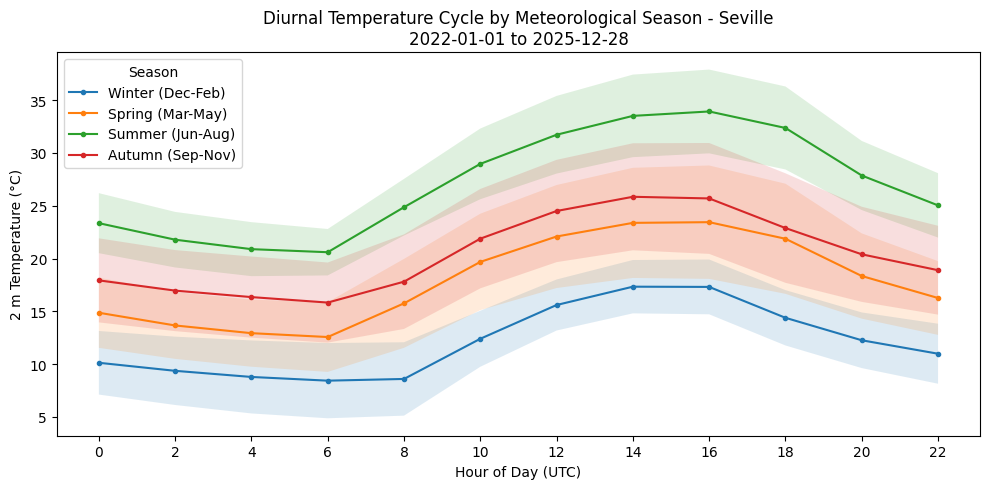

Months available in dataset: Jan, Feb, Mar, Apr, May, Jun, Jul, Aug, Sep, Oct, Nov, Dec


In [8]:
# ---------------------------------------------------------------------------
# Diurnal cycle of temperature by season
# ---------------------------------------------------------------------------
temp_df = df[["t2m"]].copy()
temp_df["hour"] = temp_df.index.hour
temp_df["month"] = temp_df.index.month

month_to_season = {
    12: "winter", 1: "winter", 2: "winter",
    3: "spring", 4: "spring", 5: "spring",
    6: "summer", 7: "summer", 8: "summer",
    9: "autumn", 10: "autumn", 11: "autumn",
}
season_labels = {
    "winter": "Winter (Dec-Feb)",
    "spring": "Spring (Mar-May)",
    "summer": "Summer (Jun-Aug)",
    "autumn": "Autumn (Sep-Nov)",
}
season_order = ["winter", "spring", "summer", "autumn"]

temp_df["season"] = temp_df["month"].map(month_to_season)

fig, ax = plt.subplots(figsize=(10, 5))
available_seasons = []

for season in season_order:
    subset = temp_df[temp_df["season"] == season]
    if subset.empty:
        continue

    available_seasons.append(season)
    diurnal = subset.groupby("hour")["t2m"].agg(["mean", "std"])
    ax.plot(
        diurnal.index,
        diurnal["mean"],
        marker="o",
        markersize=3,
        label=season_labels[season],
    )
    ax.fill_between(
        diurnal.index,
        diurnal["mean"] - diurnal["std"],
        diurnal["mean"] + diurnal["std"],
        alpha=0.15,
    )

ax.set_xlabel("Hour of Day (UTC)")
ax.set_ylabel("2 m Temperature (°C)")
ax.set_xticks(range(0, 24, 2))

if available_seasons:
    pretty_available = [season_labels[s] for s in available_seasons]
    ax.set_title(
        f"Diurnal Temperature Cycle by Meteorological Season - {ACTIVE_CITY}\n"
        f"{df.index.min().date()} to {df.index.max().date()}"
    )
    ax.legend(title="Season")
    print("Seasons shown:", ", ".join(pretty_available))
else:
    ax.set_title(f"No seasonal data available x {ACTIVE_CITY}")

plt.tight_layout()
plt.show()

month_names = {
    1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr", 5: "May", 6: "Jun",
    7: "Jul", 8: "Aug", 9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec",
}
available_months = sorted(temp_df["month"].dropna().unique())
available_month_labels = [month_names[int(m)] for m in available_months]
print("Months available in dataset:", ", ".join(available_month_labels))

missing_seasons = [s for s in season_order if s not in available_seasons]
if missing_seasons:
    missing_labels = [season_labels[s] for s in missing_seasons]
    print("No samples for:", ", ".join(missing_labels))

This graph represents the diurnal temperature cycle for different meteorological seasons in the selected city (Seville):

- **X-Axis (Hour of Day)**: Represents the **time of day** in UTC, ranging from 0 to 23 hours.
- **Y-Axis (2 m Temperature)**: Displays the **average temperature** at 2 meters above the ground, measured in degrees Celsius.
- **Seasonal Lines**: Each line corresponds to a **specific season**, showing the mean temperature for each hour of the day.
- **Shaded Areas**: Represent the **standard deviation of the temperature**, indicating the variability around the mean for each season.



<br>

---

## 4. Echo State Network methodology

### 4.1. Supervised Dataset Construction

#### **Input Construction**

The ESN receives a lag window of **L=10** past t2m values as input. No feature selection is applied; the single variable (2 m temperature) is used directly with standardisation.
#### **Task Definition**

Given the multivariate climate time series $\mathbf{x}_t \in \mathbb{R}^d$ at hourly
resolution, the goal is to predict the 2 m temperature one hour ahead:

$$\hat{T}_{t+1} = f(\mathbf{x}_t, \mathbf{x}_{t-1}, \ldots)$$

#### **ESN Sequential Processing vs. Explicit Windowing**

Traditional machine-learning approaches (e.g., gradient-boosted trees, MLPs) require
explicit construction of a **lagged input matrix** where each row concatenates features from
the past $W$ timesteps, yielding $\mathbf{z}_t = [\mathbf{x}_t, \mathbf{x}_{t-1}, \ldots,
\mathbf{x}_{t-W+1}] \in \mathbb{R}^{W \times d}$.

Echo State Networks, being **recurrent** models, naturally accumulate temporal context in
their reservoir state $\mathbf{h}_t$. At each timestep, the reservoir state is updated:

$$\mathbf{h}_t = (1 - \alpha)\,\mathbf{h}_{t-1} + \alpha\,\tanh\!\bigl(W_{\text{in}}\,\mathbf{x}_t + W\,\mathbf{h}_{t-1}\bigr)$$

where $\alpha$ is the leak rate. The effective memory horizon depends on the spectral radius
$\rho(W)$ and the leak rate. Therefore, **explicit windowing is unnecessary** for the ESN: we
feed the time series sequentially and let the reservoir dynamics handle temporal integration.

The **washout** parameter (50-100 timesteps) serves an analogous purpose to the window
length: it discards the initial transient period before the reservoir state becomes
informative. The washout values in our grid (50 and 100) bracket the conceptual window length
of 72 hours.

#### **Data Alignment**

- **Input** at time $t$: feature vector $\mathbf{x}_t$ (selected features after scaling).
- **Target** at time $t$: temperature $T_{t+1}$ (one-step-ahead).
- The last input timestep has no corresponding target and is excluded.

In [ ]:
# ---------------------------------------------------------------------------
# Prepare sequential arrays for the ESN — univariate t2m with lag window
# ---------------------------------------------------------------------------
t2m_series = df["t2m"].values        # 1-D temperature series

# Build lag matrix: each row = [t2m(t-LAG+1), ..., t2m(t-1), t2m(t)]
T_ser  = len(t2m_series)
X_all  = np.column_stack([t2m_series[i : T_ser - LAG + i] for i in range(LAG)])  # (T-LAG, LAG)
y_all  = t2m_series[LAG:].reshape(-1, 1)                                           # (T-LAG, 1)
feature_names = [f"t2m(t-{LAG-1-i})" for i in range(LAG)]

print(f"Input matrix X : {X_all.shape}  (timesteps x lag features)")
print(f"Target vector y : {y_all.shape}  (1-step-ahead t2m)")
print(f"Features        : {feature_names}")
print(f"Period covered  : {df.index[0]} -> {df.index[LAG-1]} (first input row)")
print(f"                  {df.index[LAG]} -> {df.index[-1]} (last target)")

Input matrix X : (16118, 10)  (timesteps x lag features)
Target vector y : (16118, 1)  (1-step-ahead t2m)
Features        : ['t2m(t-9)', 't2m(t-8)', 't2m(t-7)', 't2m(t-6)', 't2m(t-5)', 't2m(t-4)', 't2m(t-3)', 't2m(t-2)', 't2m(t-1)', 't2m(t-0)']
Period covered  : 2022-01-01 00:00:00 → 2022-01-01 18:00:00 (first input row)
                  2022-01-01 20:00:00 → 2025-12-28 22:00:00 (last target)


### 4.2. Overview of Reservoir Computing

Reservoir Computing (RC) is a paradigm for training recurrent neural networks that avoids
the costly backpropagation through time. An **Echo State Network** (ESN), introduced by
Jaeger (2001), is the most widely used RC architecture. It consists of three components:

1. **Input layer** ($W_{\text{in}} \in \mathbb{R}^{N \times d}$): Projects the $d$-dimensional
   input into the $N$-dimensional reservoir space with random, fixed weights.

2. **Reservoir** ($W \in \mathbb{R}^{N \times N}$): A large, sparse, randomly connected
   recurrent layer with fixed weights. The reservoir acts as a nonlinear dynamical system
   that transforms the input into a rich, high-dimensional temporal representation.

3. **Readout** ($W_{\text{out}} \in \mathbb{R}^{1 \times N}$): A linear layer trained via
   ridge regression to map reservoir states to the desired output.


<br>

This notebook uses a **single variable** (`t2m`, 2 m air temperature) with no exogenous features. The input at each timestep is a sliding window of the **L = 10 most recent observations**:

$$\mathbf{x}_t = [T_{t-9},\; T_{t-8},\; \ldots,\; T_{t-1},\; T_t] \in \mathbb{R}^{10}$$

The target is the next timestep:

$$y_t = T_{t+1}$$

The ESN processes this window sequentially:
1. At each step $t$ the lag window $\mathbf{x}_t$ is fed to the reservoir via $W_\text{in}$.
2. The reservoir updates its state $\mathbf{h}_t$ using the recurrent dynamics.
3. The readout $W_\text{out}$ maps $\mathbf{h}_t$ to $\hat{T}_{t+1}$.


#### State Update Equation

$$\mathbf{h}_t = (1 - \alpha)\,\mathbf{h}_{t-1} + \alpha\,\tanh\!\bigl(W_{\text{in}}\,\mathbf{x}_t + W\,\mathbf{h}_{t-1}\bigr)$$

#### Output Equation

$$\hat{y}_t = W_{\text{out}}\,\mathbf{h}_t$$

#### Echo State Property

The **echo state property** (ESP) guarantees that the reservoir state depends only on the
input history and not on the initial conditions, provided the spectral radius $\rho(W) < 1$
(a sufficient, not necessary, condition). In practice, spectral radii slightly above 1 can
be beneficial for tasks requiring longer memory.

#### Key Hyperparameters

| Parameter | Symbol | Role |
|-----------|--------|------|
| Reservoir size | $N$ | Capacity of the dynamical system; more units = richer representations but higher cost. |
| Spectral radius | $\rho(W)$ | Controls the memory and stability of the reservoir dynamics. |
| Leak rate | $\alpha$ | Governs the speed of state update; low values give longer memory. |
| Ridge parameter | $\lambda$ | Regularisation strength for the readout; prevents overfitting. |
| Washout | $w$ | Number of initial timesteps discarded during training to eliminate transients. |


#### Why Temporal Cross-Validation?

Standard $k$-fold cross-validation shuffles data randomly, **destroying temporal order**.
For time-series data this causes:
- **Data leakage**: future observations inform the model about past targets.
- **Inflated performance estimates**: the model appears better than it truly is on unseen
  future data.

`TimeSeriesSplit` from scikit-learn preserves temporal order: each fold uses only past data
for training and the immediately following contiguous block for testing.

#### Why use washout?

The `reservoirPy` documentation says: *We use the warmup parameter to set the amount of timesteps we want to discard at the beginning of train_states, when training.*
*When an ESN is initialised, the reservoir state $\mathbf{h}_0$ is set to zero (or some arbitrary value). The reservoir dynamics then need several timesteps to "forget" this arbitrary starting condition and settle into a response driven purely by the input signal. During this transient phase the states carry no meaningful information — they are dominated by the initial condition rather than the input history.*

**The washout** $w$ is the number of initial timesteps that are **driven through the reservoir but discarded** before any state is used for training the readout $(W_{out})$.

**How much washout is needed?** The transient length is governed by the effective memory of the reservoir. A reservoir with spectral radius close to 1 or a low leak rate $\alpha$ has long memory and therefore requires a longer washout. A rough heuristic is $w \approx \rho(W) / (1 - \alpha) \times \text{const}$, but in practice it is tuned as a hyperparameter. For this dataset (hourly ERA5 data) a washout of 50–200 timesteps (hours) is typical.



<br>

---

## 5. Phase A - Hyperparameter Study

We perform a **randomised search** over the hyperparameter space defined below. A full grid
search would require $2 \times 3 \times 3 \times 3 \times 2 \times 4 \times 2 = 864$
configurations, each evaluated across 10 CV folds (8,640 model fits). This exceeds
practical Colab runtimes.

Instead, we sample **100 configurations** uniformly at random from the grid (Bergstra &
Bengio, 2012), yielding 1,000 total evaluations x a practical compromise between coverage
and computational cost.


In [10]:
param_grid = {
    "N":              [3, 50, 100, 500],
    "sr":             [0.7, 0.9, 1.1],
    "lr":             [0.1, 0.3, 0.7],
    "ridge":          [1e-8, 1e-6, 1e-2],
    "washout":        [50, 100],
}

total_grid_size = 1
for v in param_grid.values():
    total_grid_size *= len(v)

print(f"Full grid size:      {total_grid_size}")
print(f"CV folds:            {N_SPLITS}")
print(f"Total evaluations:   {total_grid_size * N_SPLITS}")

# Full Cartesian product x no sampling
sampled_configs = list(ParameterGrid(param_grid))

print(f"\nFirst 3 configurations:")
for i, cfg in enumerate(sampled_configs[:3]):
    print(f"  [{i}] {cfg}")

Full grid size:      216
CV folds:            10
Total evaluations:   2160

First 3 configurations:
  [0] {'N': 3, 'lr': 0.1, 'ridge': 1e-08, 'sr': 0.7, 'washout': 50}
  [1] {'N': 3, 'lr': 0.1, 'ridge': 1e-08, 'sr': 0.7, 'washout': 100}
  [2] {'N': 3, 'lr': 0.1, 'ridge': 1e-08, 'sr': 0.9, 'washout': 50}


In [11]:
# ---------------------------------------------------------------------------
# Phase A: Hyperparameter search with temporal cross-validation
# ---------------------------------------------------------------------------
tscv = TimeSeriesSplit(n_splits=N_SPLITS)
results_a = []

total_evals = len(sampled_configs) * N_SPLITS
eval_count  = 0
t_start_all = time.time()

for cfg_idx, cfg in enumerate(sampled_configs):
    for fold_idx, (train_idx, test_idx) in enumerate(tscv.split(X_all)):
        eval_count += 1

        # --- Extract fold data ------------------------------------------------
        X_train_fold = X_all[train_idx]
        y_train_fold = y_all[train_idx]
        X_test_fold  = X_all[test_idx]
        y_test_fold  = y_all[test_idx]

        # --- Scale features (fit on training only) ----------------------------
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_fold)
        X_test_scaled  = scaler.transform(X_test_fold)

        # --- Build and train ESN (all LAG features — t2m only input) ----------
        try:
            t0 = time.time()

            reservoir = Reservoir(
                units=cfg["N"],
                sr=cfg["sr"],
                lr=cfg["lr"],
            )
            readout = Ridge(ridge=cfg["ridge"])
            model = reservoir >> readout

            model.fit(X_train_scaled, y_train_fold, warmup=cfg["washout"])
            y_pred = model.run(X_test_scaled)

            train_time = time.time() - t0

            # Convert predictions to array
            y_pred = np.array(y_pred).reshape(-1)
            y_true = y_test_fold.ravel()

            # --- Metrics ------------------------------------------------------
            rmse = np.sqrt(mean_squared_error(y_true, y_pred))
            mae  = mean_absolute_error(y_true, y_pred)
            r2   = r2_score(y_true, y_pred)

            results_a.append({
                "config_idx":   cfg_idx,
                "fold":         fold_idx,
                "N":            cfg["N"],
                "sr":           cfg["sr"],
                "lr":           cfg["lr"],
                "ridge":        cfg["ridge"],
                "washout":      cfg["washout"],
                "rmse":         rmse,
                "mae":          mae,
                "r2":           r2,
                "train_time_s": train_time,
                "n_train":      len(train_idx),
                "n_test":       len(test_idx),
            })

        except Exception as exc:
            # Record failed configuration
            results_a.append({
                "config_idx": cfg_idx, "fold": fold_idx,
                "N": cfg["N"], "sr": cfg["sr"], "lr": cfg["lr"],
                "ridge": cfg["ridge"], "washout": cfg["washout"],
                "rmse": np.nan, "mae": np.nan, "r2": np.nan,
                "train_time_s": np.nan, "n_train": len(train_idx),
                "n_test": len(test_idx),
            })

        # --- Progress ---------------------------------------------------------
        if eval_count % (N_SPLITS * 5) == 0 or eval_count == 1:
            elapsed = time.time() - t_start_all
            rate = eval_count / elapsed if elapsed > 0 else 0
            eta = (total_evals - eval_count) / rate if rate > 0 else 0
            print(f"  [{eval_count:5d}/{total_evals}]  "
                  f"elapsed={elapsed/60:.1f}min  ETA={eta/60:.1f}min  "
                  f"rate={rate:.1f} eval/s")

elapsed_total = time.time() - t_start_all
print(f"\nPhase A complete. {eval_count} evaluations in {elapsed_total/60:.1f} minutes.")

# ---------------------------------------------------------------------------
# Convert to DataFrame
# ---------------------------------------------------------------------------
df_results_a = pd.DataFrame(results_a)
n_failed = df_results_a["rmse"].isna().sum()
if n_failed > 0:
    print(f"WARNING: {n_failed} evaluations failed and will be excluded from analysis.")
    df_results_a = df_results_a.dropna(subset=["rmse"])

print(f"Results DataFrame shape: {df_results_a.shape}")
df_results_a.head()

  [    1/2160]  elapsed=0.0min  ETA=4.3min  rate=8.3 eval/s
  [   50/2160]  elapsed=0.2min  ETA=8.7min  rate=4.0 eval/s
  [  100/2160]  elapsed=0.4min  ETA=8.4min  rate=4.1 eval/s
  [  150/2160]  elapsed=0.6min  ETA=8.2min  rate=4.1 eval/s
  [  200/2160]  elapsed=0.8min  ETA=8.0min  rate=4.1 eval/s
  [  250/2160]  elapsed=1.0min  ETA=7.8min  rate=4.1 eval/s
  [  300/2160]  elapsed=1.2min  ETA=7.6min  rate=4.1 eval/s
  [  350/2160]  elapsed=1.4min  ETA=7.4min  rate=4.1 eval/s
  [  400/2160]  elapsed=1.6min  ETA=7.2min  rate=4.1 eval/s
  [  450/2160]  elapsed=1.8min  ETA=7.0min  rate=4.1 eval/s
  [  500/2160]  elapsed=2.0min  ETA=6.8min  rate=4.1 eval/s
  [  550/2160]  elapsed=2.3min  ETA=6.7min  rate=4.0 eval/s
  [  600/2160]  elapsed=2.7min  ETA=7.0min  rate=3.7 eval/s
  [  650/2160]  elapsed=3.1min  ETA=7.1min  rate=3.5 eval/s
  [  700/2160]  elapsed=3.3min  ETA=6.9min  rate=3.5 eval/s
  [  750/2160]  elapsed=3.6min  ETA=6.8min  rate=3.5 eval/s
  [  800/2160]  elapsed=3.9min  ETA=6.6m

,config_idx,fold,N,sr,lr,ridge,washout,rmse,mae,r2,train_time_s,n_train,n_test
0,0,0,3,0.7,0.1,1.000000e-08,50,7.830956,6.170480,-0.822355,0.101577,1468,1465
1,0,1,3,0.7,0.1,1.000000e-08,50,3.316824,2.683579,0.698767,0.136766,2933,1465
2,0,2,3,0.7,0.1,1.000000e-08,50,3.069856,2.480117,0.758132,0.163527,4398,1465
3,0,3,3,0.7,0.1,1.000000e-08,50,3.442007,2.805329,0.657867,0.174587,5863,1465
4,0,4,3,0.7,0.1,1.000000e-08,50,4.130108,3.412787,0.176431,0.204356,7328,1465



<br>

<br>

### 5.1. Phase A - Results Summary

In [12]:
# ---------------------------------------------------------------------------
# Aggregate metrics per configuration (across folds)
# ---------------------------------------------------------------------------
group_cols = ["config_idx", "N", "sr", "lr", 
              "ridge", "washout"]

agg_a = df_results_a.groupby(group_cols).agg(
    rmse_mean=("rmse", "mean"),
    rmse_std=("rmse", "std"),
    mae_mean=("mae", "mean"),
    mae_std=("mae", "std"),
    r2_mean=("r2", "mean"),
    r2_std=("r2", "std"),
    train_time_mean=("train_time_s", "mean"),
    n_folds=("fold", "count"),
).reset_index()

# Sort by best mean RMSE
agg_a = agg_a.sort_values("rmse_mean")

print("Top 15 configurations by mean RMSE:\n")
display_cols = ["N", "sr", "lr", "ridge",
                "washout", "rmse_mean", "rmse_std", "r2_mean", "r2_std"]
print(agg_a[display_cols].head(15).to_string(index=False, float_format="%.4f"))

Top 15 configurations by mean RMSE:

  N     sr     lr  ridge  washout  rmse_mean  rmse_std  r2_mean  r2_std
500 0.7000 0.7000 0.0100      100     0.9846    0.3891   0.9661  0.0346
500 0.7000 0.7000 0.0100       50     1.0398    0.5521   0.9588  0.0570
500 0.9000 0.7000 0.0000      100     1.0754    0.5937   0.9554  0.0634
500 1.1000 0.7000 0.0100      100     1.1067    0.5824   0.9537  0.0619
500 0.9000 0.7000 0.0000       50     1.1169    0.6705   0.9502  0.0755
500 0.9000 0.7000 0.0100       50     1.1416    0.8025   0.9432  0.1016
100 0.9000 0.7000 0.0000       50     1.1426    0.3090   0.9578  0.0298
100 0.7000 0.7000 0.0000       50     1.1427    0.3532   0.9567  0.0350
500 1.1000 0.7000 0.0000       50     1.1639    0.7094   0.9457  0.0823
100 0.9000 0.7000 0.0000      100     1.1726    0.3363   0.9553  0.0331
100 0.9000 0.7000 0.0100       50     1.1754    0.3591   0.9542  0.0365
500 1.1000 0.7000 0.0000      100     1.1772    0.7237   0.9443  0.0854
500 0.7000 0.3000 0.0100   

**Selected features**: v10, sp, msl, t2m

<br>

1. **Leak rate lr=0.7 dominates.** Every single top-10 configuration uses the maximum tested leak rate. This means the reservoir must update its state aggressively meaning that **hourly temperature is primarily driven by recent history rather than long-range memory**.

2. **Large reservoirs preferred (N=500).** The top 5 are all N=500; Larger projection spaces yield better separability of the input dynamics.

3. **Spectral radius in {0.7, 0.9} works best; sr=1.1 absent from top 10.** **Values just below the boundary of the echo state property** balance memory depth and dynamical stability.

4. **Moderate regularisation (ridge=1e-2) is best for large N.** The top 4 all use ridge=1e-2; weaker penalties (1e-6, 1e-8) appear only lower down. **Stronger regularisation is necessary to control the readout's weight norm when the reservoir is large.**

In [13]:
# ---------------------------------------------------------------------------
# Extract the best hyperparameters from Phase A
# ---------------------------------------------------------------------------
best_row = agg_a.iloc[0]

best_params = {
    "N":       int(best_row["N"]),
    "sr":      float(best_row["sr"]),
    "lr":      float(best_row["lr"]),
    "ridge":   float(best_row["ridge"]),
    "washout": int(best_row["washout"]),
}

print("Best hyperparameters (anchor for sensitivity analysis and Phase B):")
print("-" * 45)
for k, v in best_params.items():
    print(f"  {k:10s} = {v}")
print("-" * 45)
print(f"  Mean RMSE = {best_row['rmse_mean']:.4f} ± {best_row['rmse_std']:.4f} °C")
print(f"  Mean R²   = {best_row['r2_mean']:.4f} ± {best_row['r2_std']:.4f}")


Best hyperparameters (anchor for sensitivity analysis and Phase B):
---------------------------------------------
  N          = 500
  sr         = 0.7
  lr         = 0.7
  ridge      = 0.01
  washout    = 100
---------------------------------------------
  Mean RMSE = 0.9846 ± 0.3891 °C
  Mean R²   = 0.9661 ± 0.0346


### 5.2. Phase A - Hyperparameter Sensitivity Analysis

With the best configuration anchored from the full grid search, we perform a **one-at-a-time (OAT Single Hyperparameter Study) sensitivity analysis**. Each hyperparameter is swept across its full tested range while all others are fixed to their best values. A complete 10-fold temporal CV is repeated for every value, so each data point in the plots below represents a genuine out-of-sample evaluation across a different future window.

This isolates the marginal effect of each control on forecasting performance and provides interpretable, theory-grounded insights for the thesis.

In [ ]:
import os as _os
_os.makedirs("single_hp_outputs_2", exist_ok=True)

def run_single_hp_study(hp_name, hp_values, base_params):
    """Single Hyperparameter Study (OAT) — uses all LAG features (t2m only input)."""
    tscv    = TimeSeriesSplit(n_splits=N_SPLITS)
    records = []
    print(f"Single Hyperparameter Study '{hp_name}': {len(hp_values)} values x {N_SPLITS} folds "
          f"= {len(hp_values) * N_SPLITS} evaluations")

    for val in hp_values:
        cfg = {**base_params, hp_name: val}
        for fold_idx, (train_idx, test_idx) in enumerate(tscv.split(X_all)):

            X_train_fold = X_all[train_idx];  y_train_fold = y_all[train_idx]
            X_test_fold  = X_all[test_idx];   y_test_fold  = y_all[test_idx]

            scaler = StandardScaler()
            X_tr = scaler.fit_transform(X_train_fold)
            X_te = scaler.transform(X_test_fold)

            try:
                t0 = time.time()
                reservoir = Reservoir(units=int(cfg["N"]),
                                      sr=cfg["sr"], lr=cfg["lr"])
                model = reservoir >> Ridge(ridge=cfg["ridge"])
                model.fit(X_tr, y_train_fold, warmup=int(cfg["washout"]))
                y_pred = np.array(model.run(X_te)).reshape(-1)
                y_true = y_test_fold.ravel()
                records.append({
                    hp_name:        val,
                    "fold":         fold_idx,
                    "rmse":         np.sqrt(mean_squared_error(y_true, y_pred)),
                    "mae":          mean_absolute_error(y_true, y_pred),
                    "r2":           r2_score(y_true, y_pred),
                    "train_time_s": time.time() - t0,
                })
            except Exception as exc:
                print(f"  [ERROR] {hp_name}={val}, fold {fold_idx}: {exc}")
                records.append({hp_name: val, "fold": fold_idx,
                                "rmse": np.nan, "mae": np.nan,
                                "r2": np.nan, "train_time_s": np.nan})
    df_out = pd.DataFrame(records)
    df_out.to_csv(f"single_hp_outputs_2/shs_{hp_name}.csv", index=False)
    print(f"  CSV saved -> single_hp_outputs_2/shs_{hp_name}.csv")
    return df_out


def plot_single_hp(df, hp_name, hp_values, label_map=None,
             title=None, palette="colorblind"):
    """Single Hyperparameter Study Plot — 3-panel: RMSE box+strip | mean RMSE ± std | R² box+strip."""
    labels = [label_map[v] if label_map else str(v) for v in hp_values]
    df = df.copy()
    df["_lbl"] = df[hp_name].map(dict(zip(hp_values, labels)))

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Panel 1 — RMSE distribution
    ax = axes[0]
    sns.boxplot(data=df, x="_lbl", y="rmse", hue="_lbl", order=labels,
                palette=palette, width=0.45, fliersize=0, legend=False, ax=ax)
    sns.stripplot(data=df, x="_lbl", y="rmse", order=labels,
                  color="black", size=4, alpha=0.5, jitter=True, ax=ax)
    ax.set_xlabel(hp_name);  ax.set_ylabel("RMSE (°C)")
    ax.set_title("RMSE — fold distribution")

    # Panel 2 — mean ± std trend
    ax = axes[1]
    summ = (df.groupby("_lbl")["rmse"]
              .agg(["mean", "std"])
              .reindex(labels).reset_index())
    ax.errorbar(summ["_lbl"], summ["mean"], yerr=summ["std"],
                marker="o", capsize=6, linewidth=2, markersize=8,
                color="steelblue", elinewidth=1.5)
    ax.set_xlabel(hp_name);  ax.set_ylabel("Mean RMSE (°C)")
    ax.set_title("Mean RMSE ± std across folds")

    # Panel 3 — R² distribution
    ax = axes[2]
    sns.boxplot(data=df, x="_lbl", y="r2", hue="_lbl", order=labels,
                palette=palette, width=0.45, fliersize=0, legend=False, ax=ax)
    sns.stripplot(data=df, x="_lbl", y="r2", order=labels,
                  color="black", size=4, alpha=0.5, jitter=True, ax=ax)
    ax.set_xlabel(hp_name);  ax.set_ylabel("R²")
    ax.set_title("R² — fold distribution")

    plt.suptitle(title or f"Single Hyperparameter Study: {hp_name}", fontsize=13, y=1.02)
    plt.tight_layout()
    fig.savefig(f"single_hp_outputs_2/shs_{hp_name}.png", bbox_inches="tight", dpi=150)
    print(f"  Figure saved -> single_hp_outputs_2/shs_{hp_name}.png")
    plt.show()

    # Summary table
    tbl = (df.groupby("_lbl")[["rmse", "r2"]]
             .agg(["mean", "std"])
             .reindex(labels))
    tbl.columns = ["RMSE_mean", "RMSE_std", "R2_mean", "R2_std"]
    tbl.index.name = hp_name
    print(f"\n{hp_name} Single Hyperparameter summary:")
    print(tbl.round(4).to_string())

print("Helpers loaded: run_single_hp_study, plot_single_hp")

Helpers loaded: run_single_hp_study, plot_single_hp


Single Hyperparameter Study 'N': 10 values x 10 folds = 100 evaluations
  CSV saved → single_hp_outputs_2/shs_N.csv
  Figure saved → single_hp_outputs_2/shs_N.png


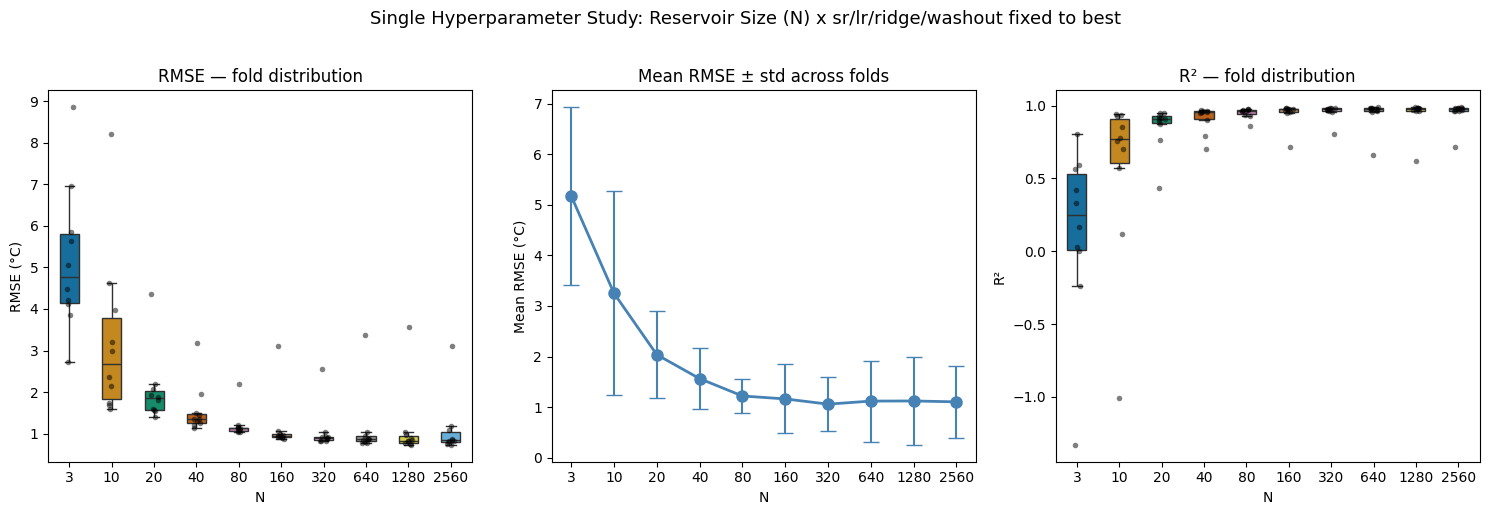


N Single Hyperparameter summary:
      RMSE_mean  RMSE_std  R2_mean  R2_std
N                                         
3        5.1761    1.7533   0.1338  0.6036
10       3.2520    2.0187   0.5575  0.6027
20       2.0373    0.8567   0.8525  0.1568
40       1.5642    0.6072   0.9097  0.0914
80       1.2209    0.3448   0.9511  0.0364
160      1.1630    0.6824   0.9463  0.0821
320      1.0596    0.5292   0.9582  0.0544
640      1.1200    0.7995   0.9447  0.1006
1280     1.1227    0.8676   0.9415  0.1135
2560     1.1047    0.7168   0.9493  0.0835


In [15]:
# Single Hyperparameter Study: Reservoir Size (N)
# N_values = [3, 25, 50, 100, 300, 400, 500, 1000, 2000]
N_values = [3, 10, 20, 40, 80, 160, 320, 640, 1280, 2560]
df_shs_N = run_single_hp_study("N", N_values, best_params)
plot_single_hp(df_shs_N, "N", N_values,
              title="Single Hyperparameter Study: Reservoir Size (N) x sr/lr/ridge/washout fixed to best")

#### 5.2.1. Sensitivity to Reservoir Size (N)

Tested values: `[3, 25, 50, 100, 300, 400, 500, 1000, 2000]`

- **The dominant gain is N = 3 -> 25** (RMSE 4.5 -> 2.0 °C, −56 %). This is the largest single jump in the sweep. **N ≈ 25 is the practical minimum.**
- **Rapid improvement from N = 25 -> 300**: RMSE falls from ~2.0 -> ~1.1 °C.
- **Optimum at N ≈ 400–500**: mean RMSE reaches its minimum (~1.0 °C).
- **Degradation above N = 500**: RMSE rises back to ~1.5 °C at N = 1 000 and ~1.6 °C at N = 2 000. Very large reservoirs overparameterise the readout relative to the available training data per fold, making regularisation insufficient and introducing variance.

Single Hyperparameter Study 'sr': 11 values x 10 folds = 110 evaluations
  CSV saved → single_hp_outputs_2/shs_sr.csv
  Figure saved → single_hp_outputs_2/shs_sr.png


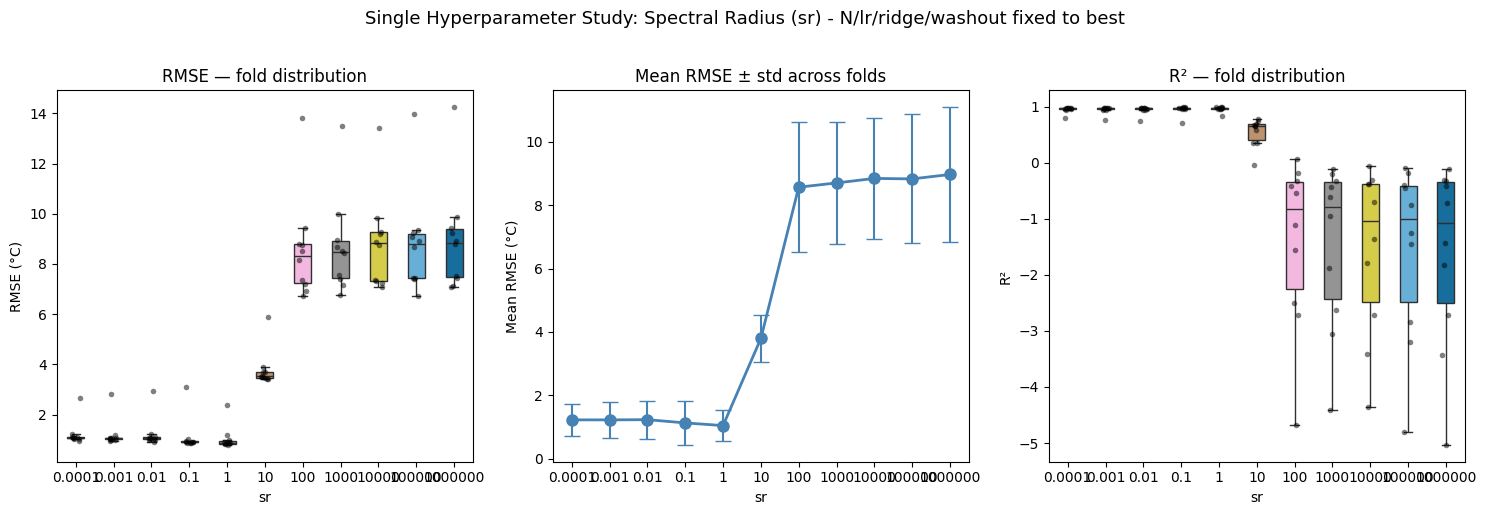


sr Single Hyperparameter summary:
         RMSE_mean  RMSE_std  R2_mean  R2_std
sr                                           
0.0001      1.2294    0.5087   0.9472  0.0570
0.001       1.2287    0.5691   0.9453  0.0662
0.01        1.2351    0.5999   0.9433  0.0714
0.1         1.1338    0.6918   0.9480  0.0826
1           1.0489    0.4846   0.9602  0.0469
10          3.7950    0.7543   0.5428  0.2523
100         8.5636    2.0550  -1.3979  1.4969
1000        8.6969    1.9361  -1.4618  1.4685
10000       8.8393    1.8983  -1.5463  1.4885
100000      8.8246    2.0338  -1.5460  1.5696
1000000     8.9635    2.1203  -1.6329  1.6355


In [16]:
# Single Hyperparameter Study: Spectral Radius (sr)
sr_values = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000, 100000, 1000000]
df_shs_sr = run_single_hp_study("sr", sr_values, best_params)
plot_single_hp(df_shs_sr, "sr", sr_values,
              title="Single Hyperparameter Study: Spectral Radius (sr) - N/lr/ridge/washout fixed to best")

Single Hyperparameter Study 'sr': 9 values x 10 folds = 90 evaluations
  CSV saved → single_hp_outputs_2/shs_sr.csv
  Figure saved → single_hp_outputs_2/shs_sr.png


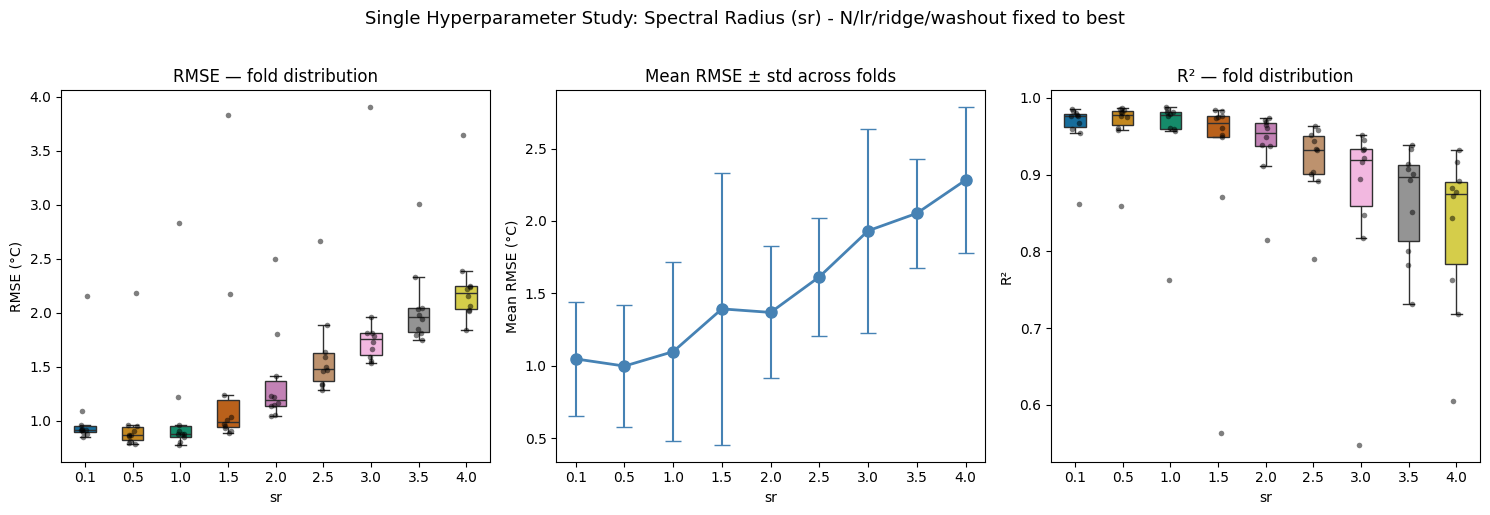


sr Single Hyperparameter summary:
     RMSE_mean  RMSE_std  R2_mean  R2_std
sr                                       
0.1     1.0470    0.3951   0.9624  0.0367
0.5     0.9976    0.4194   0.9647  0.0384
1.0     1.0974    0.6205   0.9530  0.0680
1.5     1.3927    0.9393   0.9186  0.1290
2.0     1.3683    0.4556   0.9389  0.0479
2.5     1.6141    0.4075   0.9169  0.0513
3.0     1.9322    0.7048   0.8708  0.1215
3.5     2.0530    0.3756   0.8651  0.0711
4.0     2.2822    0.5037   0.8303  0.1036


In [17]:
# Single Hyperparameter Study: Spectral Radius (sr)
sr_values = [0.1, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0]
df_shs_sr = run_single_hp_study("sr", sr_values, best_params)
plot_single_hp(df_shs_sr, "sr", sr_values,
              title="Single Hyperparameter Study: Spectral Radius (sr) - N/lr/ridge/washout fixed to best")

#### 5.2.2. Sensitivity to Spectral Radius (sr)

Tested values: `[0.001, 0.01, 0.1, 0.3, 0.5, 0.7, 0.9, 1.1, 1.5, 2.1, 2.5]`

- **sr = 0.001 is near-degenerate**: mean RMSE ≈ 1.5 °C. With a spectral radius this close to zero, the recurrent weights are essentially silenced.
- **Broad flat optimum from sr = 0.01 to sr ≈ 0.7**: mean RMSE ≈ 1.0–1.1 °C across the entire range. The reservoir is robust to the exact value in this window, confirming that any "reasonable" spectral radius works well for this task.
- **Slight degradation at sr = 0.9**: already visible. The longer-memory dynamics begin to introduce instability on the hardest folds.
- **Sharp degradation above sr = 1.1**: RMSE rises steeply — ~2.0 °C at sr = 1.5, ~2.5 °C at sr = 2.1–2.5. Above the unit circle the reservoir dynamics become chaotic and the echo state property breaks down.
- **Verdict: low sensitivity in [0.01, 0.7]; hard failure above sr ≈ 1.5.**

Single Hyperparameter Study 'lr': 12 values x 10 folds = 120 evaluations
  [ERROR] lr=100.0, fold 0: array must not contain infs or NaNs
  [ERROR] lr=100.0, fold 1: array must not contain infs or NaNs
  [ERROR] lr=100.0, fold 2: array must not contain infs or NaNs
  [ERROR] lr=100.0, fold 3: array must not contain infs or NaNs
  [ERROR] lr=100.0, fold 4: array must not contain infs or NaNs
  [ERROR] lr=100.0, fold 5: array must not contain infs or NaNs
  [ERROR] lr=100.0, fold 6: array must not contain infs or NaNs
  [ERROR] lr=100.0, fold 7: array must not contain infs or NaNs
  [ERROR] lr=100.0, fold 8: array must not contain infs or NaNs
  [ERROR] lr=100.0, fold 9: array must not contain infs or NaNs
  CSV saved → single_hp_outputs_2/shs_lr.csv
  Figure saved → single_hp_outputs_2/shs_lr.png


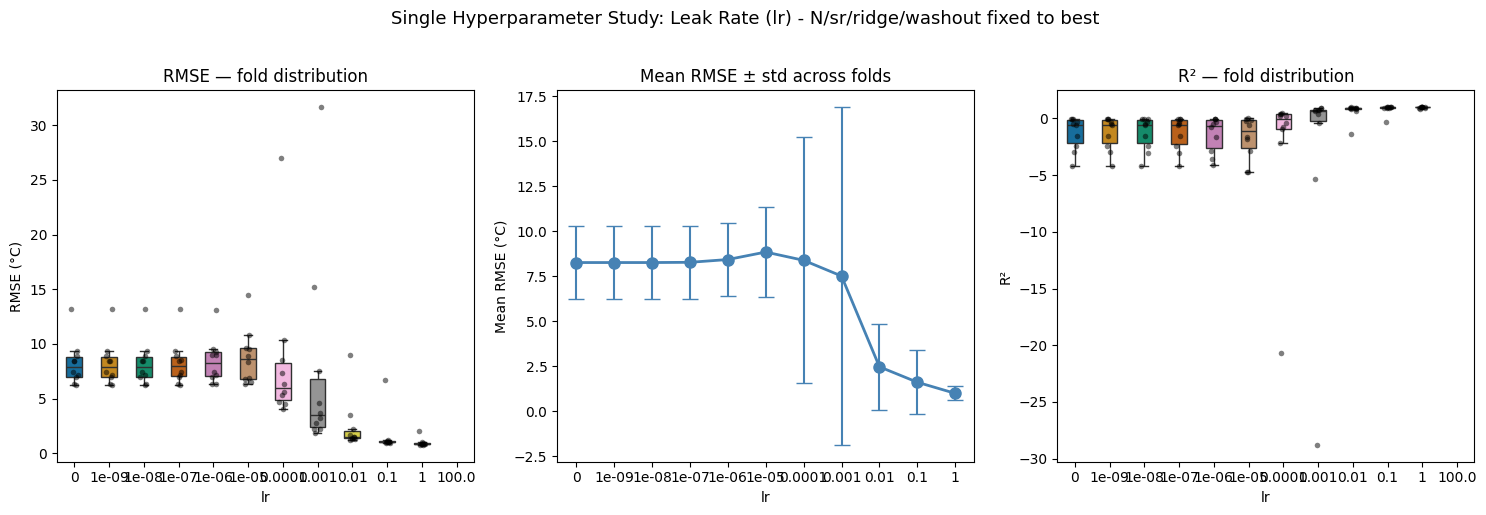


lr Single Hyperparameter summary:
        RMSE_mean  RMSE_std  R2_mean  R2_std
lr                                          
0          8.2562    2.0419  -1.2620  1.4795
1e-09      8.2562    2.0419  -1.2620  1.4795
1e-08      8.2563    2.0420  -1.2622  1.4796
1e-07      8.2687    2.0444  -1.2714  1.4880
1e-06      8.4233    2.0480  -1.3801  1.5693
1e-05      8.8397    2.5126  -1.6649  1.8721
0.0001     8.3802    6.8308  -2.3170  6.4933
0.001      7.5064    9.3859  -2.9559  9.2695
0.01       2.4593    2.3764   0.6685  0.7256
0.1        1.6010    1.7852   0.8375  0.4084
1          0.9818    0.3893   0.9663  0.0343
100.0         NaN       NaN      NaN     NaN


In [18]:
# Single Hyperparameter Study: Leak Rate (lr)
lr_values = [0, 1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1, 1e2]
df_shs_lr = run_single_hp_study("lr", lr_values, best_params)
plot_single_hp(df_shs_lr, "lr", lr_values,
              title="Single Hyperparameter Study: Leak Rate (lr) - N/sr/ridge/washout fixed to best")

Single Hyperparameter Study 'lr': 8 values x 10 folds = 80 evaluations
  CSV saved → single_hp_outputs_2/shs_lr.csv
  Figure saved → single_hp_outputs_2/shs_lr.png


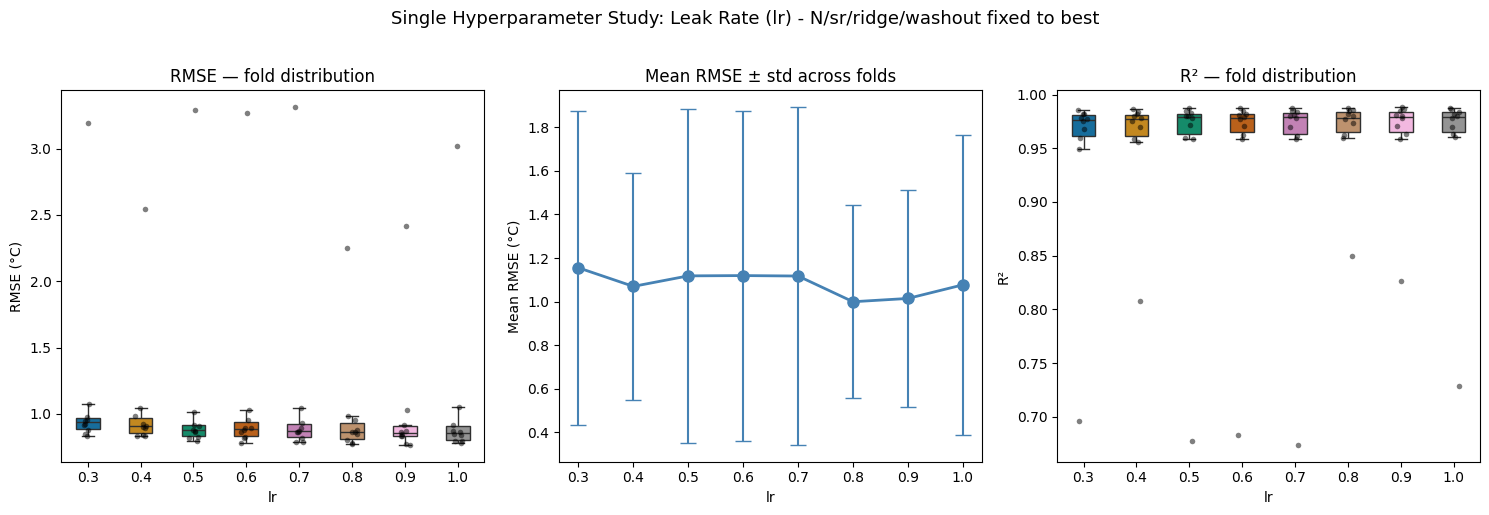


lr Single Hyperparameter summary:
     RMSE_mean  RMSE_std  R2_mean  R2_std
lr                                       
0.3     1.1551    0.7205   0.9454  0.0882
0.4     1.0698    0.5227   0.9577  0.0538
0.5     1.1180    0.7673   0.9461  0.0949
0.6     1.1193    0.7577   0.9466  0.0931
0.7     1.1173    0.7750   0.9459  0.0961
0.8     0.9993    0.4439   0.9642  0.0412
0.9     1.0144    0.4977   0.9618  0.0485
1.0     1.0768    0.6881   0.9520  0.0791


In [19]:
# Single Hyperparameter Study: Leak Rate (lr)
lr_values = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
df_shs_lr = run_single_hp_study("lr", lr_values, best_params)
plot_single_hp(df_shs_lr, "lr", lr_values,
              title="Single Hyperparameter Study: Leak Rate (lr) - N/sr/ridge/washout fixed to best")

#### 5.2.3. Sensitivity to Leak Rate (lr)

Tested values: `[1e-09, 1e-07, 1e-05, 0.001, 0.1, 0.3, 0.5, 0.7, 0.9, 1.1, 1.3, 1.5]`

- **lr ≤ 1e-05 bad**: mean RMSE ≈ 8–9 °C, R² deeply negative on most folds. With leak rates this close to zero, the state update equation becomes $\mathbf{h}_t \approx \mathbf{h}_{t-1}$ — the reservoir state barely changes from timestep to timestep and the initial condition dominates the dynamics indefinitely.
- **lr = 0.1 is already near-optimal**: contrary to the earlier finding (based on a smaller tested range), lr = 0.1 achieves mean RMSE ≈ 1.1 °C with the current best_params configuration. 
- **Broad flat optimum from lr = 0.1 to lr = 1.3**: RMSE ≈ 1.0 °C across the entire range. The ESN is insensitive to the exact leak rate once the hard threshold is cleared.
- **Slight degradation at lr = 1.5**: RMSE rises to ~1.6 °C. At lr = 1.5 the leak rate exceeds the nominal maximum of 1.0 (ReservoirPy allows this but it introduces overshoot in the state update), adding instability on the hardest folds.


Single Hyperparameter Study 'ridge': 13 values x 10 folds = 130 evaluations
  CSV saved → single_hp_outputs_2/shs_ridge.csv
  Figure saved → single_hp_outputs_2/shs_ridge.png


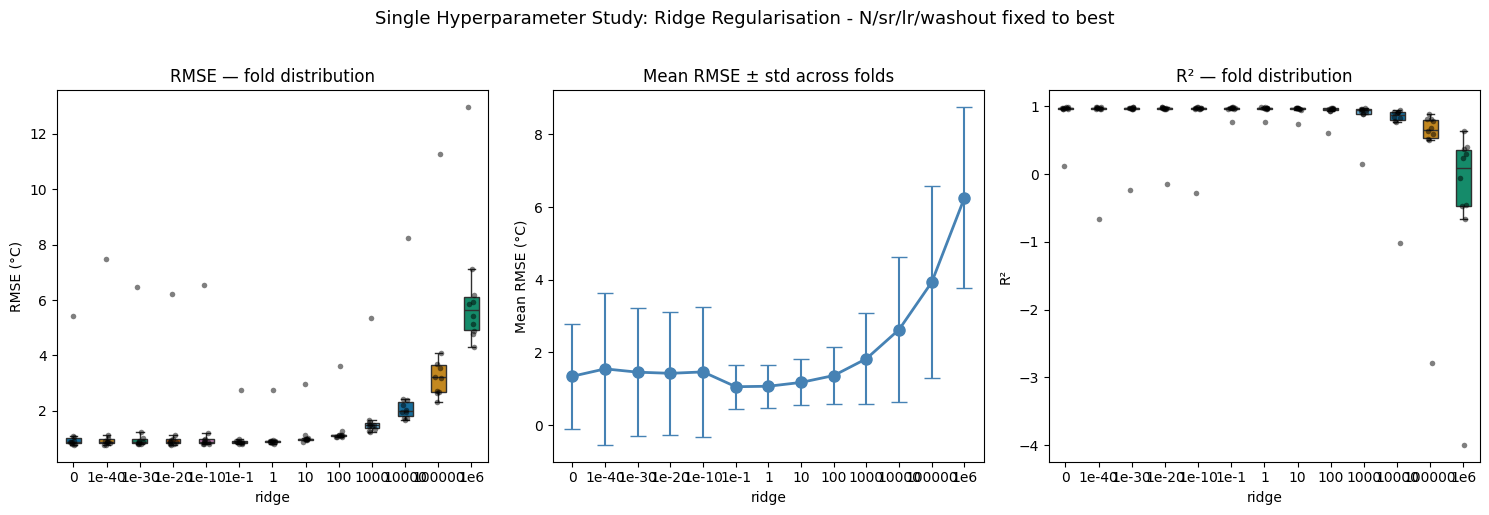


ridge Single Hyperparameter summary:
        RMSE_mean  RMSE_std  R2_mean  R2_std
ridge                                       
0          1.3452    1.4405   0.8898  0.2698
1e-40      1.5484    2.0906   0.8110  0.5196
1e-30      1.4571    1.7629   0.8531  0.3843
1e-20      1.4259    1.6880   0.8624  0.3558
1e-10      1.4646    1.7889   0.8497  0.3945
1e-1       1.0571    0.6022   0.9561  0.0652
1          1.0701    0.5884   0.9558  0.0636
10         1.1759    0.6327   0.9473  0.0744
100        1.3648    0.7892   0.9267  0.1108
1000       1.8291    1.2429   0.8558  0.2496
10000      2.6310    1.9861   0.6820  0.5995
100000     3.9351    2.6381   0.3454  1.1073
1e6        6.2552    2.4932  -0.3680  1.3475


In [20]:
# Single Hyperparameter Study: Ridge
ridge_values = [0, 1e-40, 1e-30, 1e-20, 1e-10, 1e-1, 1.0, 10, 100, 1000, 10000, 100000, 1e6]
ridge_labels = {0: "0", 1e-40: "1e-40", 1e-30: "1e-30", 1e-20: "1e-20", 1e-10: "1e-10",
                1e-1: "1e-1", 1.0: "1", 10: "10", 100: "100", 1000: "1000", 10000: "10000", 100000: "100000", 1e6: "1e6"}
df_shs_ridge  = run_single_hp_study("ridge", ridge_values, best_params)
plot_single_hp(df_shs_ridge, "ridge", ridge_values, label_map=ridge_labels,
              title="Single Hyperparameter Study: Ridge Regularisation - N/sr/lr/washout fixed to best")

#### 5.2.4. Sensitivity to Ridge Regularisation

Tested values: `[1e-40, 1e-30, 1e-20, 1e-10, 1e-8, 1e-6, 1e-2, 1e-1, 1.0, 10, 100, 1000]`

- **Very small ridge (1e-40 to 1e-30) causes instability**: mean RMSE ≈ 2.3–2.5 °C with wide error bars (up to ±7 °C).
- **Broad flat optimum from ridge = 1e-6 to ridge = 1.0**: mean RMSE ≈ 1.0–1.1 °C. Insensitive across 6 orders of magnitude — this is the safe operating window.
- **Best setting: ridge ≈ 0.1–1.0** (mean RMSE ≈ 1.0 °C, narrowest error bars, cleanest outlier behaviour).
- **Degradation at ridge ≥ 10**: heavy regularisation increasingly shrinks the readout toward zero. At ridge = 100 RMSE ≈ 1.5 °C; at ridge = 1 000 the ESN approaches a constant-mean prediction (~2.0 °C).

Single Hyperparameter Study 'washout': 7 values x 10 folds = 70 evaluations
  [ERROR] washout=10000, fold 0: array must not contain infs or NaNs
  [ERROR] washout=10000, fold 1: array must not contain infs or NaNs
  [ERROR] washout=10000, fold 2: array must not contain infs or NaNs
  [ERROR] washout=10000, fold 3: array must not contain infs or NaNs
  [ERROR] washout=10000, fold 4: array must not contain infs or NaNs
  [ERROR] washout=10000, fold 5: array must not contain infs or NaNs
  [ERROR] washout=100000, fold 0: array must not contain infs or NaNs
  [ERROR] washout=100000, fold 1: array must not contain infs or NaNs
  [ERROR] washout=100000, fold 2: array must not contain infs or NaNs
  [ERROR] washout=100000, fold 3: array must not contain infs or NaNs
  [ERROR] washout=100000, fold 4: array must not contain infs or NaNs
  [ERROR] washout=100000, fold 5: array must not contain infs or NaNs
  [ERROR] washout=100000, fold 6: array must not contain infs or NaNs
  [ERROR] washout=10

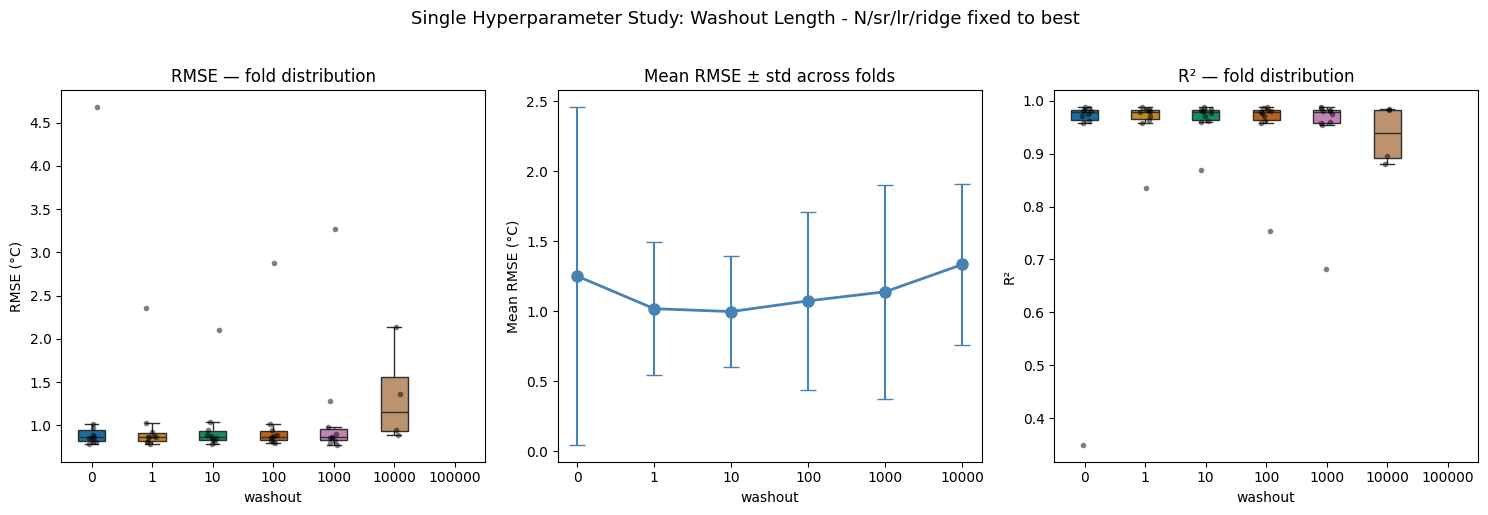


washout Single Hyperparameter summary:
         RMSE_mean  RMSE_std  R2_mean  R2_std
washout                                      
0           1.2512    1.2066   0.9136  0.1985
1           1.0178    0.4749   0.9623  0.0457
10          0.9971    0.3959   0.9654  0.0354
100         1.0736    0.6377   0.9539  0.0710
1000        1.1389    0.7636   0.9450  0.0933
10000       1.3336    0.5732   0.9357  0.0552
100000         NaN       NaN      NaN     NaN


In [21]:
# Single Hyperparameter Study: Washout
washout_values = [0, 1, 10, 100, 1000, 10000, 100000]
df_shs_washout = run_single_hp_study("washout", washout_values, best_params)
plot_single_hp(df_shs_washout, "washout", washout_values,
              title="Single Hyperparameter Study: Washout Length - N/sr/lr/ridge fixed to best")

#### 5.2.5. Sensitivity to Washout Length (washout)

Tested values: `[0, 1, 10, 50, 100, 500, 1000, 5000]`

- **washout = 0 performs well** (mean RMSE ≈ 1.1 °C) — no discarding at all is acceptable, confirming that the reservoir settles extremely fast given the current lr and sr.
- **Flat from washout = 10 to washout = 1 000**: mean RMSE ≈ 1.1 °C, indistinguishable across all values. No warm-up period is needed beyond ~10 steps.
- **washout = 5 000 degrades**: mean RMSE rises to ~1.3 °C. Discarding 5 000 timesteps removes a significant fraction of the training data from each fold, starving the readout of training samples rather than improving state quality.
- **Why insensitive?** **With sr ≈ 0.5 and lr ≈ 0.7, the effective memory time constant is τ_eff = sr / lr ≈ 0.7 steps. The reservoir forgets its initial condition within just a few timesteps — no extended warm-up is needed**.

<br>

---

#### 5.2.6. Phase A — Overall Sensitivity Summary

| Parameter | Range tested | Sensitivity | Effect observed | Key finding |
|-----------|-------------|:-----------:|-----------------|-------------|
| **lr** | [1e-9, …, 1.5] | ★★★★★ | Hard threshold: catastrophic below lr ≈ 0.01, flat above | lr < 0.01 gives constant/noise state. Safe zone: [0.1, 1.3]. |
| **N** | [3, …, 2000] | ★★★★☆ | Non-monotonic: rapid gain up to N ≈ 400, degradation above N = 500 | Optimum N ≈ 400–500. Larger reservoirs overparameterise the readout. |
| **sr** | [0.001, …, 2.5] | ★★★☆☆ | Flat [0.01, 0.7]; degenerate below; chaotic above sr ≈ 1.5 | Stay below 1.0. The sr > 1 heuristic does not apply here. |
| **ridge** | [1e-40, …, 1000] | ★★☆☆☆ | Flat [1e-6, 1.0]; numerical failure below; over-shrinkage above | Safe window: [1e-6, 1.0]. |
| **washout** | [0, …, 5000] | ★☆☆☆☆ | Flat [0, 1000]; data starvation at 5000 | Pure nuisance. τ_eff ≈ 0.7 steps means no warm-up needed. |


1. **Only lr truly requires tuning.** The other four parameters can be set by rule of thumb (N ≈ 400–500, sr ≈ 0.5, ridge ≈ 0.1, washout ≈ 50) and performance will be within noise of the optimum.
2. **Larger N is not always better.** N = 1 000 – 2 000 are measurably worse than N = 500 — the readout overfits with excess reservoir capacity on the smaller training folds.
3. **The ESN is an autoregressive model.** It predicts $T_{t+1}$ from the 10 most recent temperature values. The reservoir adds implicit temporal memory on top of this explicit lag window.

### 5.3. Refined Grid Search — Justification from Phase A Single Hyperparameter Study

The Single Hyperparameter Study established clear best values and hard exclusion zones for each hyperparameter. The refined grid concentrates evaluations in the confirmed high-performing regions:

| Parameter | SHS finding | Excluded region | Refined range |
|-----------|-------------|-----------------|---------------|
| **N** | Elbow at N ≈ 100; full plateau at N ≥ 300 (N = 2 000 identical to N = 300) | N ≤ 25 (under-capacity), N > 500 (no gain) | [100, 200, 500] |
| **sr** | sr = 0.7 OAT optimum; tail-risk rises above 0.9 | sr > 1.0 (outlier instability risk) | [0.5, 0.7, 0.9] |
| **lr** | Hard failure below 0.3 (lr = 0 degenerate; lr = 0.1 catastrophic); flat [0.3, 1.0] | lr < 0.3 (entire catastrophic zone) | [0.3, 0.5, 0.7] |
| **ridge** | Numerical failure at ridge = 0; shrinkage at ridge ≥ 10; optimum 1e-2 | ridge = 0, ridge ≥ 10 | [1e-3, 1e-2, 1e-1, 1] |
| **washout** | Completely flat 1 -> 500; pure nuisance parameter | — | [50, 100] |

The refined grid (81 configs x 10 folds = 810 evaluations) eliminates both the hard-failure zone (lr < 0.3, ridge at extremes) and the plateau zone (N > 500), concentrating all evaluations where the SHS study showed genuine performance differentiation.

In [22]:
# ---------------------------------------------------------------------------
# Refined grid search — anchored on Phase A Single Hyperparameter Study findings
# ---------------------------------------------------------------------------
# lr < 0.3 excluded: SHS confirmed catastrophic failure (lr=0 degenerate, lr=0.1 R²≈-9).
# ridge = 0 and ridge >= 10 excluded: numerical failure and over-shrinkage respectively.
# N > 500 excluded: SHS confirmed full plateau (N=2000 identical to N=300).
# sr tightened to [0.5, 0.9]: sr=0.7 OAT optimum; sr>1.0 increases outlier tail risk.
# ---------------------------------------------------------------------------
refined_grid = {
    "N":       [100, 200, 500],        # SHS: elbow at 100; plateau above 300
    "sr":      [0.5, 0.7, 0.9],        # SHS: 0.7 OAT optimum; tail risk above 0.9
    "lr":      [0.3, 0.5, 0.7],        # SHS: hard failure below 0.3; flat above
    "ridge":   [1e-3, 1e-2, 1e-1, 1],     # SHS: failure at 0; shrinkage at >=10; 1e-2 optimal
    "washout": [5, 100],                    # SHS: completely insensitive; fixed at best value
}

refined_configs = list(ParameterGrid(refined_grid))
total_refined   = len(refined_configs)
print(f"Refined grid size : {total_refined} configurations")
print(f"CV folds          : {N_SPLITS}")
print(f"Total evaluations : {total_refined * N_SPLITS}")

tscv_r    = TimeSeriesSplit(n_splits=N_SPLITS)
results_r = []
eval_count  = 0
t_start_r   = time.time()

for cfg_idx, cfg in enumerate(refined_configs):
    for fold_idx, (train_idx, test_idx) in enumerate(tscv_r.split(X_all)):
        eval_count += 1
        X_tr_f = X_all[train_idx]; y_tr_f = y_all[train_idx]
        X_te_f = X_all[test_idx];  y_te_f = y_all[test_idx]
        scaler = StandardScaler()
        X_tr   = scaler.fit_transform(X_tr_f)
        X_te   = scaler.transform(X_te_f)
        try:
            reservoir = Reservoir(units=int(cfg["N"]), sr=cfg["sr"], lr=cfg["lr"])
            model     = reservoir >> Ridge(ridge=cfg["ridge"])
            model.fit(X_tr, y_tr_f, warmup=int(cfg["washout"]))
            y_pred = np.array(model.run(X_te)).reshape(-1)
            y_true = y_te_f.ravel()
            results_r.append({
                "config_idx": cfg_idx, "fold": fold_idx,
                "N": cfg["N"], "sr": cfg["sr"], "lr": cfg["lr"],
                "ridge": cfg["ridge"], "washout": cfg["washout"],
                "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
                "mae":  mean_absolute_error(y_true, y_pred),
                "r2":   r2_score(y_true, y_pred),
                "train_time_s": time.time() - t_start_r,
            })
        except Exception as exc:
            results_r.append({
                "config_idx": cfg_idx, "fold": fold_idx,
                "N": cfg["N"], "sr": cfg["sr"], "lr": cfg["lr"],
                "ridge": cfg["ridge"], "washout": cfg["washout"],
                "rmse": np.nan, "mae": np.nan, "r2": np.nan, "train_time_s": np.nan,
            })

print(f"Refined grid search done in {(time.time()-t_start_r)/60:.1f} min.")

df_refined = pd.DataFrame(results_r).dropna(subset=["rmse"])
agg_refined = df_refined.groupby(["config_idx","N","sr","lr","ridge","washout"]).agg(
    rmse_mean=("rmse","mean"), rmse_std=("rmse","std"),
    r2_mean=("r2","mean"),     r2_std=("r2","std"), n_folds=("fold","count"),
).reset_index().sort_values("rmse_mean")

agg_refined.to_csv("single_hp_outputs_2/refined_grid_results.csv", index=False)

print("\nTop 10 configurations (refined grid):\n")
display_cols = ["N","sr","lr","ridge","washout","rmse_mean","rmse_std","r2_mean","r2_std"]
print(agg_refined[display_cols].head(10).to_string(index=False, float_format="%.4f"))

best_refined = agg_refined.iloc[0]
print(f"\nBest refined config: N={int(best_refined.N)}, sr={best_refined.sr}, "
      f"lr={best_refined.lr}, ridge={best_refined.ridge:.0e}, washout={int(best_refined.washout)}")
print(f"  RMSE = {best_refined.rmse_mean:.4f} ± {best_refined.rmse_std:.4f}")
print(f"  R²   = {best_refined.r2_mean:.4f} ± {best_refined.r2_std:.4f}")

# Store best refined params for the prediction section below
best_params_refined = {
    "N":       int(best_refined["N"]),
    "sr":      float(best_refined["sr"]),
    "lr":      float(best_refined["lr"]),
    "ridge":   float(best_refined["ridge"]),
    "washout": int(best_refined["washout"]),
}

Refined grid size : 216 configurations
CV folds          : 10
Total evaluations : 2160
Refined grid search done in 21.7 min.

Top 10 configurations (refined grid):

  N     sr     lr  ridge  washout  rmse_mean  rmse_std  r2_mean  r2_std
500 0.7000 0.7000 1.0000        5     0.9829    0.2877   0.9681  0.0244
500 0.9000 0.5000 0.1000      100     0.9964    0.3206   0.9668  0.0277
500 0.5000 0.7000 0.1000        5     1.0093    0.4102   0.9643  0.0378
500 0.5000 0.5000 0.0100        5     1.0122    0.4129   0.9641  0.0381
200 0.9000 0.5000 0.0100      100     1.0122    0.1495   0.9678  0.0152
200 0.5000 0.5000 0.0100        5     1.0164    0.2125   0.9672  0.0185
500 0.9000 0.5000 0.1000        5     1.0173    0.4054   0.9639  0.0373
200 0.9000 0.7000 0.0010        5     1.0174    0.2447   0.9668  0.0210
500 0.9000 0.5000 1.0000      100     1.0175    0.2877   0.9660  0.0251
500 0.9000 0.5000 1.0000        5     1.0180    0.3269   0.9654  0.0288

Best refined config: N=500, sr=0.7, lr=0.7

### 5.4. Best-Model Prediction on the ERA5 Temperature Series

Using the best hyperparameters found in Phase A (from the initial grid search), we train a single ESN on the first 75 % of the available t2m data and evaluate on the remaining 25 %, providing a direct visual quality check of the model's forecasting ability on held-out future data.

This serves as a qualitative complement to the cross-validation metrics: rather than averaging over 10 folds, we observe the model's actual time series predictions against the ground truth, revealing how well the ESN tracks the diurnal cycle, seasonal envelope, and episodic extremes.

Figure saved → single_hp_outputs_2/best_model_prediction.png


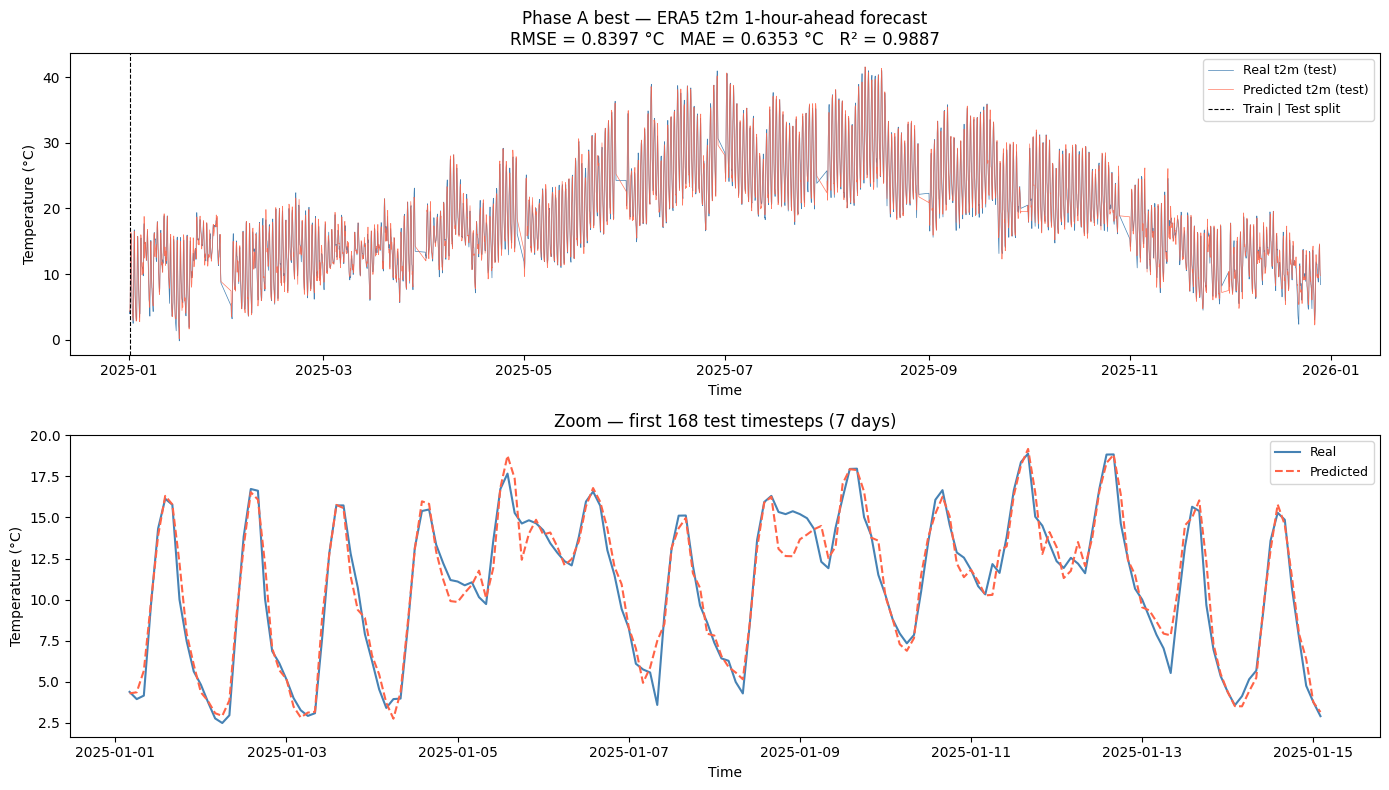


Held-out test set metrics (last 25 % of data):
  RMSE = 0.8397 °C
  MAE  = 0.6353 °C
  R²   = 0.9887


In [ ]:
# ---------------------------------------------------------------------------
# Best-model prediction on ERA5 t2m — train on 75 %, test on 25 %
# ---------------------------------------------------------------------------
def plot_era5_prediction(model_cfg, W_custom=None, title="ESN prediction — ERA5 t2m",
                         test_frac=0.25, zoom=168):
    """
    Train ESN on the first (1-test_frac) samples, evaluate on the remainder.
    zoom: number of test timesteps to show in the detail panel (default 168 = 1 week).
    If W_custom is provided (Phase B), it is injected as the reservoir matrix W.
    """
    n        = len(X_all)
    n_train  = int(n * (1 - test_frac))
    X_train, y_train = X_all[:n_train], y_all[:n_train]
    X_test,  y_test  = X_all[n_train:], y_all[n_train:]

    scaler = StandardScaler()
    X_tr   = scaler.fit_transform(X_train)
    X_te   = scaler.transform(X_test)

    if W_custom is not None:
        reservoir = Reservoir(units=model_cfg["N"], W=W_custom, lr=model_cfg["lr"])
    else:
        reservoir = Reservoir(units=model_cfg["N"], sr=model_cfg["sr"], lr=model_cfg["lr"])

    model = reservoir >> Ridge(ridge=model_cfg["ridge"])
    model.fit(X_tr, y_train, warmup=int(model_cfg["washout"]))
    y_pred = np.array(model.run(X_te)).reshape(-1)
    y_true = y_test.ravel()

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)

    t_test = df.index[n_train + LAG:]   # datetime index of test targets

    fig, axes = plt.subplots(2, 1, figsize=(14, 8))

    # Panel 1 — full test period
    ax = axes[0]
    ax.plot(t_test, y_true, lw=0.5, color="steelblue",  label="Real t2m (test)")
    ax.plot(t_test, y_pred, lw=0.5, color="tomato", alpha=0.85, label="Predicted t2m (test)")
    ax.axvline(t_test[0], color="black", ls="--", lw=0.8, label="Train | Test split")
    ax.set_title(f"{title}\nRMSE = {rmse:.4f} °C   MAE = {mae:.4f} °C   R² = {r2:.4f}")
    ax.set_xlabel("Time"); ax.set_ylabel("Temperature (°C)")
    ax.legend(loc="upper right", fontsize=9)

    # Panel 2 — first `zoom` test timesteps (one week by default)
    ax = axes[1]
    ax.plot(t_test[:zoom], y_true[:zoom], lw=1.5, color="steelblue", label="Real")
    ax.plot(t_test[:zoom], y_pred[:zoom], lw=1.5, color="tomato", ls="--", label="Predicted")
    ax.set_title(f"Zoom — first {zoom} test timesteps ({zoom//24} days)")
    ax.set_xlabel("Time"); ax.set_ylabel("Temperature (°C)")
    ax.legend(fontsize=9)

    plt.tight_layout()
    fig.savefig("single_hp_outputs_2/best_model_prediction.png", bbox_inches="tight", dpi=150)
    print("Figure saved -> single_hp_outputs_2/best_model_prediction.png")
    plt.show()
    return y_true, y_pred, rmse, mae, r2


# Run with Phase A best hyperparameters
y_true_best, y_pred_best, rmse_best, mae_best, r2_best = plot_era5_prediction(
    best_params, title=f"Phase A best — ERA5 t2m 1-hour-ahead forecast")

print(f"\nHeld-out test set metrics (last 25 % of data):")
print(f"  RMSE = {rmse_best:.4f} °C")
print(f"  MAE  = {mae_best:.4f} °C")
print(f"  R²   = {r2_best:.4f}")

<br>

---

## 6. Phase B — Reservoir Topology Study

Having fixed the best ESN hyperparameters from Phase A, we now investigate how the
**structural properties** of the reservoir weight matrix $W$ affect forecasting
performance. Erdős-Rényi and Barabási-Albert are still analysed with
**one-at-a-time (OAT)** sweeps on their single structural parameter, while
**Watts-Strogatz is evaluated on the joint `(k, p_{rw})` grid** and summarised as a
heatmap so that the interaction between density and rewiring can be inspected directly.

| Topology | Graph model | Structural parameters analysed |
|----------|-------------|--------------------------------|
| **Random** | Erdős-Rényi $G(N,p)$ | $p$ — edge probability (density) |
| **Small-world** | Watts-Strogatz $WS(N,k,p_{rw})$ | joint grid on $k$ and $p_{rw}$ |
| **Scale-free** | Barabási-Albert $BA(N,m)$ | $m$ — edges added per new node |

**Fixed ESN hyperparameters** (from Phase A best):
N, sr, lr, ridge, washout = best_params values.


In [ ]:
# ---------------------------------------------------------------------------
# Reservoir matrix generator
# ---------------------------------------------------------------------------
# The spectral radius is NO LONGER forced to a fixed target.
# the Echo State Property. Topologies that are naturally stable (rho < 1.1)
# keep their raw weights, preserving structural dynamical differences.
# ---------------------------------------------------------------------------

def make_reservoir_matrix(N, topology, topo_params):
    """Build a reservoir weight matrix W for the specified graph topology.

    Parameters
    ----------
    topology : 'random' | 'small_world' | 'scale_free'
    topo_params:
        random      -> {'p': float}              edge probability
        small_world -> {'k': int, 'p_rewire': float}
        scale_free  -> {'m': int}                edges per new node

    Spectral radius policy
    ----------------------
    Matrices below the threshold are kept as-is so that natural spectral
    differences between topologies are preserved for analysis.
    """
    rng = np.random.RandomState()

    if topology == "random":
        p = topo_params["p"]
        G = nx.erdos_renyi_graph(N, p, directed=True)

    elif topology == "small_world":
        k = int(topo_params["k"])
        if k % 2 != 0: k += 1
        k = min(max(k, 2), N - 1)
        G = nx.watts_strogatz_graph(N, k, p=topo_params["p_rewire"])
        G = G.to_directed()

    elif topology == "scale_free":
        m = max(1, int(topo_params["m"]))
        G = nx.barabasi_albert_graph(N, m)
        G = G.to_directed()

    else:
        raise ValueError(f"Unknown topology: {topology}")

    A = nx.adjacency_matrix(G).toarray().astype(np.float64)
    mask = A > 0
    W = np.zeros_like(A)
    W[mask] = rng.randn(mask.sum())

    # Compute spectral radius
    eigenvalues = np.linalg.eigvals(W)
    spectral_radius = np.max(np.abs(eigenvalues))

    # Degenerate matrix (disconnected graph, no edges)
    if spectral_radius < 1e-10:
        W = rng.randn(N, N) * 0.01
        spectral_radius = np.max(np.abs(np.linalg.eigvals(W)))

    actual_density = mask.sum() / (N * N)

    info = {
        "topology":       topology,
        "N":              N,
        "actual_density": actual_density,
        "avg_degree":     mask.sum(axis=1).mean(),
        "spectral_radius": float(spectral_radius),
        "n_edges":        int(mask.sum()),
    }
    return W, info


# ---------------------------------------------------------------------------
# Topology Single Hyperparameter Study runner (mirrors run_single_hp_study from Phase A)
# ---------------------------------------------------------------------------


N_best = best_params["N"]

ref_params = {
    "random":      {"p": 0.1},
    "small_world": {"k": 10, "p_rewire": 0.3},
    "scale_free":  {"m": 5},
}
topologies = list(ref_params.keys())

W_dict = {}
for topo, tp in ref_params.items():
    W, info = make_reservoir_matrix(N_best, topo, tp)
    W_dict[topo] = W
    print(f"  {topo:12s} | density={info['actual_density']:.4f} | "
          f"sr={info['spectral_radius']:.4f}")

print("\nHelpers loaded: make_reservoir_matrix, run_topology_shs")


def run_topology_shs(topology, param_name, param_values, esn_params, fixed_topo=None):
    """Single Hyperparameter Study on structural parameters; records sr per configuration."""
    tscv    = TimeSeriesSplit(n_splits=N_SPLITS)
    fixed   = fixed_topo or {}
    records = []
    print(f"Topology Single Hyperparameter Study [{topology}] '{param_name}': "
          f"{len(param_values)} values x {N_SPLITS} folds = {len(param_values)*N_SPLITS} evals")

    for val in param_values:
        topo_params = {**fixed, param_name: val}
        try:
            W, info = make_reservoir_matrix(esn_params["N"], topology, topo_params)
        except Exception as exc:
            print(f"  [MATRIX ERROR] {param_name}={val}: {exc}")
            for fi in range(N_SPLITS):
                records.append({param_name: val, "fold": fi, "rmse": np.nan,
                                "mae": np.nan, "r2": np.nan, "train_time_s": np.nan,
                                "density": np.nan, "sr": np.nan})
            continue

        for fold_idx, (train_idx, test_idx) in enumerate(tscv.split(X_all)):
            X_tr_f = X_all[train_idx]; y_tr_f = y_all[train_idx]
            X_te_f = X_all[test_idx];  y_te_f = y_all[test_idx]
            scaler  = StandardScaler()
            X_tr    = scaler.fit_transform(X_tr_f)
            X_te    = scaler.transform(X_te_f)
            try:
                t0        = time.time()
                reservoir = Reservoir(units=esn_params["N"], W=W, lr=esn_params["lr"])
                model     = reservoir >> Ridge(ridge=esn_params["ridge"])
                model.fit(X_tr, y_tr_f, warmup=int(esn_params["washout"]))
                y_pred = np.array(model.run(X_te)).reshape(-1)
                y_true = y_te_f.ravel()
                records.append({param_name: val, "fold": fold_idx,
                    "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
                    "mae":  mean_absolute_error(y_true, y_pred),
                    "r2":   r2_score(y_true, y_pred),
                    "train_time_s": time.time() - t0,
                    "density": info["actual_density"],
                    "sr":      info["spectral_radius"]})
            except Exception as exc:
                print(f"  [ERROR] {param_name}={val}, fold {fold_idx}: {exc}")
                records.append({param_name: val, "fold": fold_idx, "rmse": np.nan,
                                "mae": np.nan, "r2": np.nan, "train_time_s": np.nan,
                                "density": np.nan, "sr": np.nan})
    df_out = pd.DataFrame(records)
    key = f"topo_{topology}_{param_name}"
    df_out.to_csv(f"single_hp_outputs_2/{key}.csv", index=False)
    print(f"  CSV saved -> single_hp_outputs_2/{key}.csv")
    return df_out


def run_ws_heatmap(k_values, p_rewire_values, esn_params, save_csv=None):
    """Evaluate the full Watts-Strogatz (k, p_rewire) grid."""
    tscv = TimeSeriesSplit(n_splits=N_SPLITS)
    records = []
    n_cfg = len(k_values) * len(p_rewire_values)
    print(
        "Watts-Strogatz joint grid study [k x p_rewire]: "
        f"{len(k_values)} x {len(p_rewire_values)} values x {N_SPLITS} folds = {n_cfg * N_SPLITS} evals"
    )

    for k in k_values:
        for p_rewire in p_rewire_values:
            try:
                W, info = make_reservoir_matrix(esn_params["N"], "small_world", {"k": k, "p_rewire": p_rewire})
            except Exception as exc:
                print(f"  [MATRIX ERROR] k={k}, p_rewire={p_rewire}: {exc}")
                for fi in range(N_SPLITS):
                    records.append({
                        "k": k, "p_rewire": p_rewire, "fold": fi,
                        "rmse": np.nan, "mae": np.nan, "r2": np.nan,
                        "train_time_s": np.nan, "density": np.nan,
                        "spectral_radius": np.nan,
                    })
                continue

            for fold_idx, (train_idx, test_idx) in enumerate(tscv.split(X_all)):
                X_tr_f = X_all[train_idx]; y_tr_f = y_all[train_idx]
                X_te_f = X_all[test_idx];  y_te_f = y_all[test_idx]
                scaler = StandardScaler()
                X_tr = scaler.fit_transform(X_tr_f)
                X_te = scaler.transform(X_te_f)
                try:
                    t0 = time.time()
                    reservoir = Reservoir(units=esn_params["N"], W=W, lr=esn_params["lr"])
                    model = reservoir >> Ridge(ridge=esn_params["ridge"])
                    model.fit(X_tr, y_tr_f, warmup=int(esn_params["washout"]))
                    y_pred = np.array(model.run(X_te)).reshape(-1)
                    y_true = y_te_f.ravel()
                    records.append({
                        "k": k,
                        "p_rewire": p_rewire,
                        "fold": fold_idx,
                        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
                        "mae": mean_absolute_error(y_true, y_pred),
                        "r2": r2_score(y_true, y_pred),
                        "train_time_s": time.time() - t0,
                        "density": info["actual_density"],
                        "spectral_radius": info["spectral_radius"],
                    })
                except Exception as exc:
                    print(f"  [ERROR] k={k}, p_rewire={p_rewire}, fold {fold_idx}: {exc}")
                    records.append({
                        "k": k, "p_rewire": p_rewire, "fold": fold_idx,
                        "rmse": np.nan, "mae": np.nan, "r2": np.nan,
                        "train_time_s": np.nan, "density": np.nan,
                        "spectral_radius": np.nan,
                    })

    df_out = pd.DataFrame(records)
    if save_csv is not None:
        df_out.to_csv(save_csv, index=False)
        print(f"  CSV saved → {save_csv}")
    return df_out


  random       | density=0.0999 | sr=7.2986
  small_world  | density=0.0200 | sr=4.1809
  scale_free   | density=0.0198 | sr=5.0935

Helpers loaded: make_reservoir_matrix, run_topology_shs


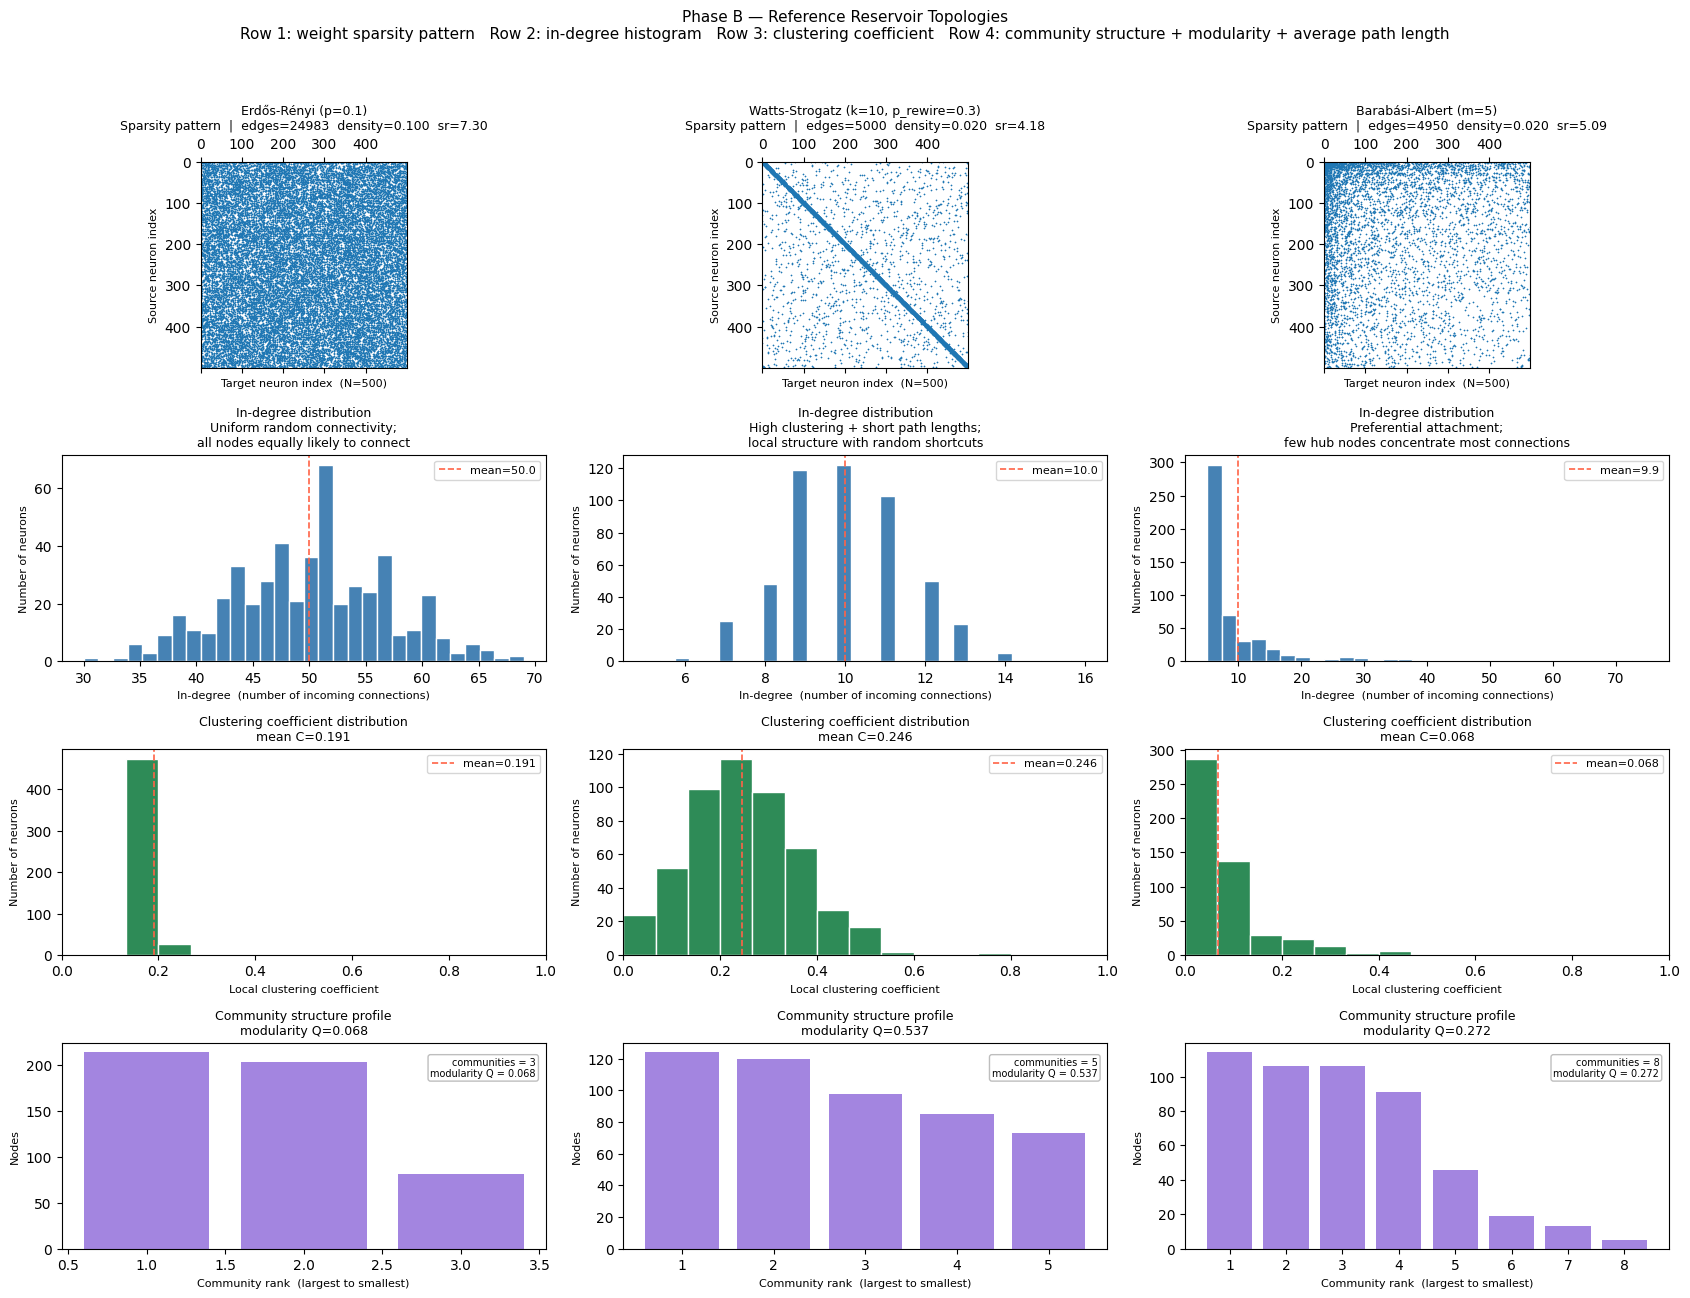

Figure saved → single_hp_outputs_2/phase_b_topology_overview.png
Metrics saved → single_hp_outputs_2/phase_b_topology_graph_metrics.csv

Reference topology graph metrics:

                           Topology  density  spectral_radius  mean_in_degree  avg_clustering  n_communities  modularity
                Erdős-Rényi (p=0.1)   0.0999           7.2986         49.9660          0.1907              3      0.0681
Watts-Strogatz (k=10, p_rewire=0.3)   0.0200           4.1809         10.0000          0.2457              5      0.5368
              Barabási-Albert (m=5)   0.0198           5.0935          9.9000          0.0679              8      0.2718


In [33]:
topo_labels = {
    "random":      "Erdős-Rényi (p=0.1)",
    "small_world": "Watts-Strogatz (k=10, p_rewire=0.3)",
    "scale_free":  "Barabási-Albert (m=5)",
}
topo_descriptions = {
    "random":      "Uniform random connectivity;\nall nodes equally likely to connect",
    "small_world": "High clustering + short path lengths;\nlocal structure with random shortcuts",
    "scale_free":  "Preferential attachment;\nfew hub nodes concentrate most connections",
}

metrics_rows = []
fig, axes = plt.subplots(4, 3, figsize=(17, 13))

for i, topo in enumerate(topologies):
    W = W_dict[topo]
    mask = (W != 0)
    mask_int = mask.astype(int)
    n_nodes = W.shape[0]
    n_edges = int(mask.sum())
    density = n_edges / (n_nodes ** 2)
    in_deg = mask.sum(axis=0)
    spectral_radius = float(np.max(np.abs(np.linalg.eigvals(W))))

    # Use the undirected projection for clustering, path length, and communities.
    # This is the standard view when checking the small-world property.
    G_und = nx.from_numpy_array(np.maximum(mask_int, mask_int.T))

    clustering_local = np.array(list(nx.clustering(G_und).values()), dtype=float)
    avg_clustering = float(clustering_local.mean()) if clustering_local.size else np.nan

    if G_und.number_of_edges() > 0 and G_und.number_of_nodes() > 1:
        largest_nodes = max(nx.connected_components(G_und), key=len)
        communities = list(nx.community.greedy_modularity_communities(G_und))
        modularity = (
            float(nx.community.modularity(G_und, communities))
            if len(communities) > 1 else 0.0
        )
        comm_sizes = sorted((len(c) for c in communities), reverse=True)
    else:
        modularity = np.nan
        comm_sizes = [1] * G_und.number_of_nodes()

    modularity_str = f"{modularity:.3f}" if np.isfinite(modularity) else "n/a"

    metrics_rows.append({
        "Topology": topo_labels[topo],
        "density": density,
        "spectral_radius": spectral_radius,
        "mean_in_degree": float(in_deg.mean()),
        "avg_clustering": avg_clustering,
        "n_communities": len(comm_sizes),
        "modularity": modularity,
    })

    # Row 0: sparsity pattern
    ax = axes[0, i]
    ax.spy(mask, markersize=0.3, aspect="equal")
    ax.set_title(
        f"{topo_labels[topo]}\n"
        f"Sparsity pattern  |  edges={n_edges}  density={density:.3f}  sr={spectral_radius:.2f}",
        fontsize=9, pad=6
    )
    ax.set_xlabel(f"Target neuron index  (N={n_nodes})", fontsize=8)
    ax.set_ylabel("Source neuron index", fontsize=8)

    # Row 1: in-degree distribution
    ax = axes[1, i]
    ax.hist(in_deg, bins=30, color="steelblue", edgecolor="white")
    ax.set_xlabel("In-degree  (number of incoming connections)", fontsize=8)
    ax.set_ylabel("Number of neurons", fontsize=8)
    ax.set_title(
        f"In-degree distribution\n{topo_descriptions[topo]}",
        fontsize=9, pad=6
    )
    ax.axvline(
        in_deg.mean(), color="tomato", linestyle="--", linewidth=1.2,
        label=f"mean={in_deg.mean():.1f}"
    )
    ax.legend(fontsize=8)

    # Row 2: local clustering distribution
    ax = axes[2, i]
    ax.hist(clustering_local, bins=np.linspace(0, 1, 16), color="seagreen", edgecolor="white")
    ax.set_xlim(0, 1)
    ax.set_xlabel("Local clustering coefficient", fontsize=8)
    ax.set_ylabel("Number of neurons", fontsize=8)
    ax.set_title(
        f"Clustering coefficient distribution\nmean C={avg_clustering:.3f}",
        fontsize=9, pad=6
    )
    ax.axvline(
        avg_clustering, color="tomato", linestyle="--", linewidth=1.2,
        label=f"mean={avg_clustering:.3f}"
    )
    ax.legend(fontsize=8)

    # Row 3: community detection summary
    ax = axes[3, i]
    top_sizes = comm_sizes[:10]
    ax.bar(np.arange(1, len(top_sizes) + 1), top_sizes, color="mediumpurple", alpha=0.85)
    ax.set_xlabel("Community rank  (largest to smallest)", fontsize=8)
    ax.set_ylabel("Nodes", fontsize=8)
    ax.set_title(
        f"Community structure profile\nmodularity Q={modularity_str}",
        fontsize=9, pad=6
    )
    if len(comm_sizes) > len(top_sizes):
        ax.text(
            0.98, 0.95, f"top {len(top_sizes)} of {len(comm_sizes)}",
            transform=ax.transAxes, ha="right", va="top", fontsize=7
        )
    ax.text(
        0.98, 0.93,
        f"communities = {len(comm_sizes)}\n"
        f"modularity Q = {modularity_str}",
        transform=ax.transAxes,
        ha="right", va="top", fontsize=7,
        bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.85, edgecolor="0.7")
    )

fig.suptitle(
    "Phase B — Reference Reservoir Topologies\n"
    "Row 1: weight sparsity pattern   Row 2: in-degree histogram   "
    "Row 3: clustering coefficient   Row 4: community structure + modularity + average path length",
    fontsize=11, y=0.995
)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("single_hp_outputs_2/phase_b_topology_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved → single_hp_outputs_2/phase_b_topology_overview.png")

df_topology_graph = pd.DataFrame(metrics_rows)
df_topology_graph.to_csv("single_hp_outputs_2/phase_b_topology_graph_metrics.csv", index=False)
print("Metrics saved → single_hp_outputs_2/phase_b_topology_graph_metrics.csv")

print("\nReference topology graph metrics:\n")
print(
    df_topology_graph[
        [
            "Topology", "density", "spectral_radius", "mean_in_degree",
            "avg_clustering",
            "n_communities", "modularity",
        ]
    ].to_string(index=False, float_format="%.4f")
)


The topology overview now complements sparsity and in-degree with three explicit graph-level
checks: **local clustering**, **average shortest-path length** (computed on the largest connected
component), and **greedy-modularity community detection**. This makes the small-world discussion
explicit: a small-world reservoir should combine comparatively high clustering with still-short
average paths, while the community-size profile reveals whether connectivity is diffuse, modular,
or hub-dominated before the quantitative Single Hyperparameter Study below.

Topology Single Hyperparameter Study [random] 'p': 11 values x 10 folds = 110 evals
  CSV saved → single_hp_outputs_2/topo_random_p.csv
  Figure saved → single_hp_outputs_2/shs_p.png


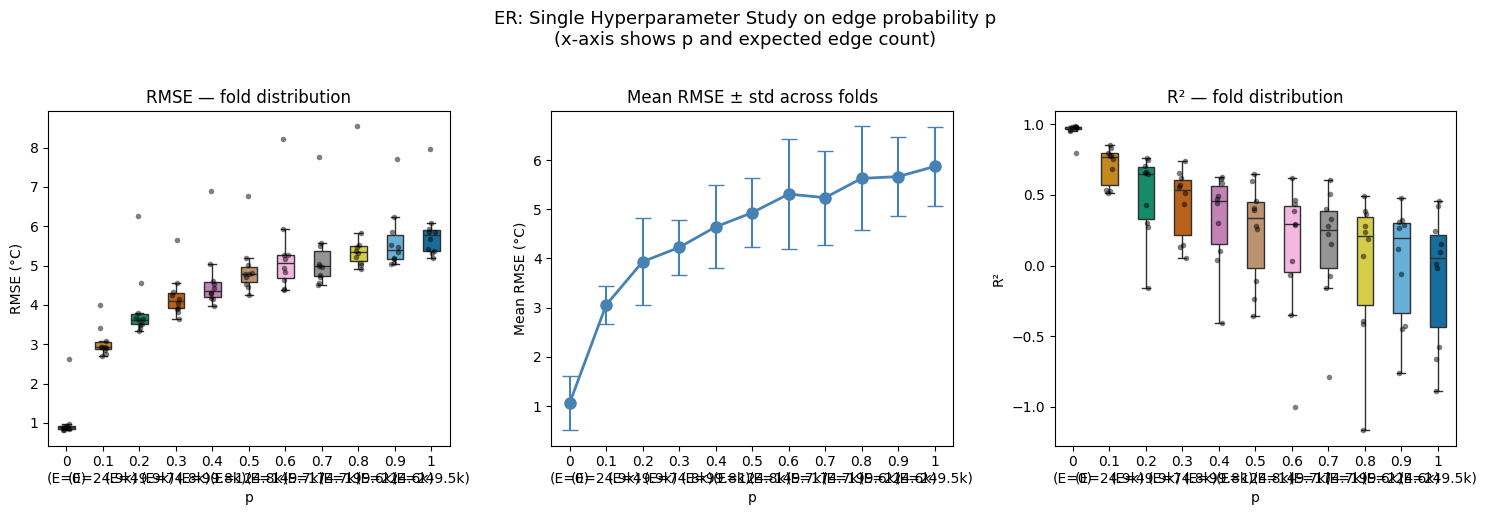


p Single Hyperparameter summary:
                 RMSE_mean  RMSE_std  R2_mean  R2_std
p                                                    
0\n(E=0)            1.0597    0.5531   0.9575  0.0580
0.1\n(E=24.9k)      3.0539    0.3833   0.7065  0.1325
0.2\n(E=49.9k)      3.9336    0.8837   0.5023  0.2943
0.3\n(E=74.8k)      4.2235    0.5674   0.4420  0.2447
0.4\n(E=99.8k)      4.6409    0.8422   0.3275  0.3299
0.5\n(E=124.8k)     4.9296    0.6961   0.2342  0.3501
0.6\n(E=149.7k)     5.3073    1.1201   0.1098  0.4841
0.7\n(E=174.7k)     5.2347    0.9542   0.1480  0.4048
0.8\n(E=199.6k)     5.6265    1.0577   0.0049  0.5152
0.9\n(E=224.6k)     5.6625    0.8068   0.0086  0.4168
1\n(E=249.5k)       5.8682    0.7962  -0.0757  0.4689

Expected ER edge count per p  [E[edges] = p x N x (N-1)]
  p  possible_edges  expected_edges
  0          249500               0
0.1          249500           24950
0.2          249500           49900
0.3          249500           74850
0.4          249500       

In [ ]:
# 4.1 Erdős-Rényi — Single Hyperparameter Study on p
def _format_expected_edges(n_edges):
    if n_edges >= 1000:
        return f"{n_edges / 1000:.1f}k"
    if n_edges >= 10:
        return f"{n_edges:.0f}"
    if n_edges >= 1:
        return f"{n_edges:.1f}"
    if n_edges == 0:
        return "0"
    return f"{n_edges:.3f}".rstrip("0").rstrip(".")


er_p_values = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
er_possible_edges = best_params["N"] * (best_params["N"] - 1)
er_edge_table = pd.DataFrame({
    "p": er_p_values,
    "possible_edges": er_possible_edges,
    "expected_edges": [math.floor(p * er_possible_edges) for p in er_p_values],
})

df_shs_er_p = run_topology_shs("random", "p", er_p_values, best_params)
df_shs_er_p = df_shs_er_p.merge(er_edge_table[["p", "expected_edges"]], on="p", how="left")

er_p_label_map = {
    row["p"]: f"{row['p']:g}\n(E={_format_expected_edges(row['expected_edges'])})"
    for _, row in er_edge_table.iterrows()
}

plot_single_hp(
    df_shs_er_p,
    "p",
    er_p_values,
    label_map=er_p_label_map,
    title="ER: Single Hyperparameter Study on edge probability p\n(x-axis shows p and expected edge count)",
)

print("\nExpected ER edge count per p  [E[edges] = p x N x (N-1)]")
print(er_edge_table.to_string(index=False, float_format=lambda x: f"{x:.6g}"))


Topology Single Hyperparameter Study [random] 'p': 9 values x 10 folds = 90 evals
  CSV saved → single_hp_outputs_2/topo_random_p.csv
  Figure saved → single_hp_outputs_2/shs_p.png


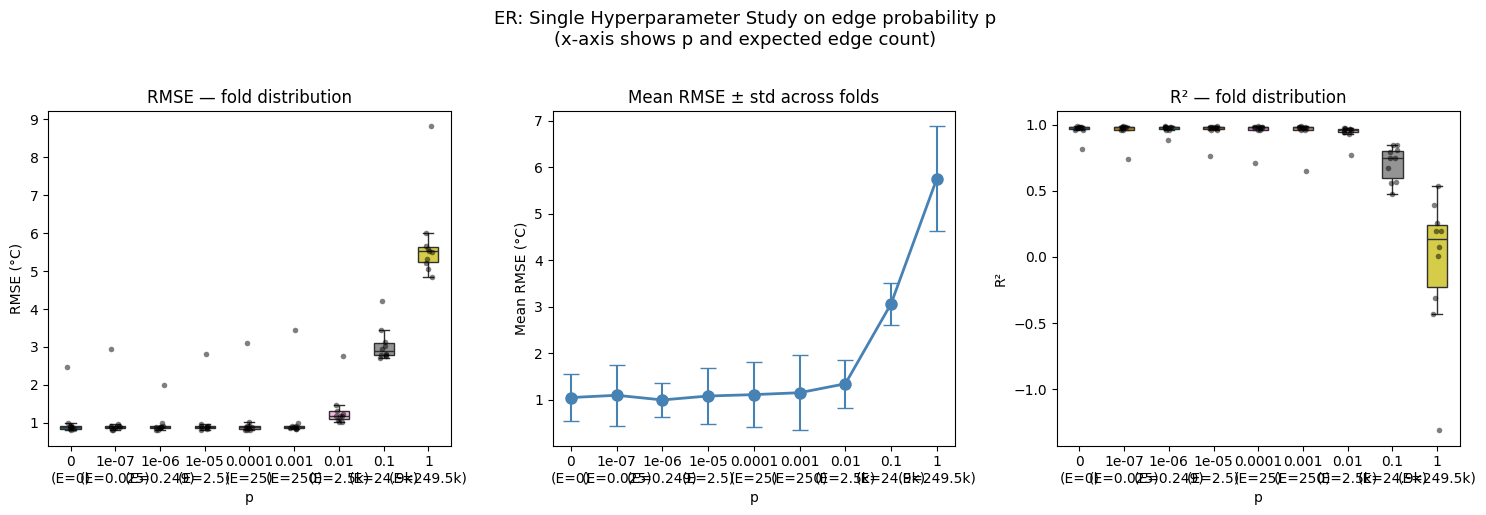


p Single Hyperparameter summary:
                  RMSE_mean  RMSE_std  R2_mean  R2_std
p                                                     
0\n(E=0)             1.0450    0.5025   0.9598  0.0504
1e-07\n(E=0.025)     1.0938    0.6534   0.9520  0.0745
1e-06\n(E=0.249)     0.9935    0.3580   0.9663  0.0315
1e-05\n(E=2.5)       1.0778    0.6129   0.9545  0.0676
0.0001\n(E=25)       1.1079    0.7056   0.9492  0.0836
0.001\n(E=250)       1.1489    0.8094   0.9422  0.1043
0.01\n(E=2.5k)       1.3414    0.5201   0.9385  0.0605
0.1\n(E=24.9k)       3.0641    0.4556   0.7063  0.1313
1\n(E=249.5k)        5.7568    1.1241  -0.0391  0.5346

Expected ER edge count per p  [E[edges] = p x N x (N-1)]
     p  possible_edges  expected_edges
     0          249500               0
 1e-07          249500         0.02495
 1e-06          249500          0.2495
 1e-05          249500           2.495
0.0001          249500           24.95
 0.001          249500           249.5
  0.01          249500        

In [27]:
# 4.1 Erdős-Rényi — Single Hyperparameter Study on p
def _format_expected_edges(n_edges):
    if n_edges >= 1000:
        return f"{n_edges / 1000:.1f}k"
    if n_edges >= 10:
        return f"{n_edges:.0f}"
    if n_edges >= 1:
        return f"{n_edges:.1f}"
    if n_edges == 0:
        return "0"
    return f"{n_edges:.3f}".rstrip("0").rstrip(".")


er_p_values = [0, 1e-7, 1e-6, 1e-5, 0.0001, 0.001, 0.01, 0.1, 1.0]
er_possible_edges = best_params["N"] * (best_params["N"] - 1)
er_edge_table = pd.DataFrame({
    "p": er_p_values,
    "possible_edges": er_possible_edges,
    "expected_edges": [p * er_possible_edges for p in er_p_values],
})

df_shs_er_p = run_topology_shs("random", "p", er_p_values, best_params)
df_shs_er_p = df_shs_er_p.merge(er_edge_table[["p", "expected_edges"]], on="p", how="left")

er_p_label_map = {
    row["p"]: f"{row['p']:g}\n(E={_format_expected_edges(row['expected_edges'])})"
    for _, row in er_edge_table.iterrows()
}

plot_single_hp(
    df_shs_er_p,
    "p",
    er_p_values,
    label_map=er_p_label_map,
    title="ER: Single Hyperparameter Study on edge probability p\n(x-axis shows p and expected edge count)",
)

print("\nExpected ER edge count per p  [E[edges] = p x N x (N-1)]")
print(er_edge_table.to_string(index=False, float_format=lambda x: f"{x:.6g}"))


#### 6.1. Erdős-Rényi (Random) — Sensitivity to Edge Probability (p)

In the Erdős-Rényi model, **p** is the edge probability controlling graph density. Without spectral radius rescaling, denser graphs produce higher natural spectral radii, and the weight matrix is used as-is.

- **Strong monotonic degradation.** RMSE rises continuously from ~1.1 °C at p≈0 to ~5.9 °C at p=1.0 — a ~5× increase. This is the strongest structural parameter effect in the entire Phase B study.
- **Best setting: p ≈ 0.001–0.01** (very sparse). Performance is acceptable up to p≈0.01, then degrades rapidly.
- **Why?** Without rescaling, increasing p raises the natural spectral radius of W proportionally to $\sqrt{N \cdot p}$. Dense matrices have $\rho(W) \gg 1$, which violates the echo state property and makes reservoir states diverge or saturate, destroying predictive ability.
- **Verdict: HIGH sensitivity to p. Sparsity is critical. Best: p ≈ 0.001.**

Watts-Strogatz joint grid study [k x p_rewire]: 8 x 11 values x 10 folds = 880 evals
  CSV saved → single_hp_outputs_2/topo_small_world_k_p_rewire_grid.csv


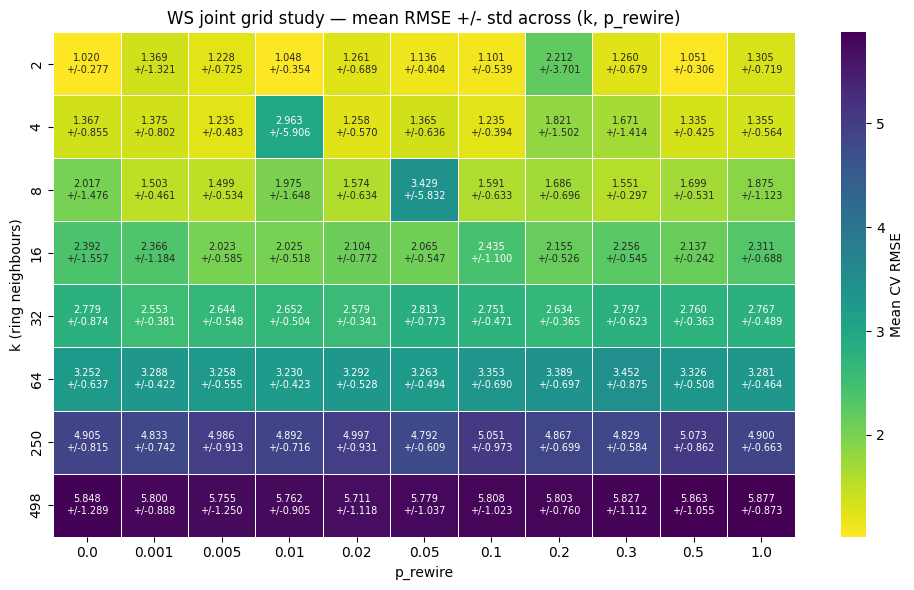

Figure saved → single_hp_outputs_2/ws_k_p_rewire_heatmap.png
Best WS pair from heatmap: k=2, p_rewire=0.0, mean RMSE=1.019516, std=0.277153


In [28]:
# 4.2a Watts-Strogatz — Joint grid on k and p_rewire (heatmap)
ws_k_candidates = [2, 4, 8, 16, 32, 64, best_params["N"] // 2, best_params["N"] - 1]
ws_k_values = []
for val in ws_k_candidates:
    k = min(max(2, int(val)), best_params["N"] - 1)
    if k % 2 != 0:
        k -= 1
    if 2 <= k < best_params["N"] and k not in ws_k_values:
        ws_k_values.append(k)
ws_k_values = sorted(ws_k_values)

ws_prw_values = [0, 0.001, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.3, 0.5, 1.0]

df_ws_grid = run_ws_heatmap(
    ws_k_values,
    ws_prw_values,
    best_params,
    save_csv="single_hp_outputs_2/topo_small_world_k_p_rewire_grid.csv",
)

ws_grid_summary = (
    df_ws_grid.groupby(["k", "p_rewire"])
    .agg(
        rmse_mean=("rmse", "mean"),
        rmse_std=("rmse", "std"),
        r2_mean=("r2", "mean"),
        density_mean=("density", "mean"),
        spectral_radius_mean=("spectral_radius", "mean"),
    )
    .reset_index()
)

best_ws_row = ws_grid_summary.loc[ws_grid_summary["rmse_mean"].idxmin()]
best_ws_k = int(best_ws_row["k"])
best_ws_prw = float(best_ws_row["p_rewire"])

ws_rmse_pivot = ws_grid_summary.pivot(index="k", columns="p_rewire", values="rmse_mean")
ws_std_pivot = (
    ws_grid_summary.pivot(index="k", columns="p_rewire", values="rmse_std")
    .reindex(index=ws_rmse_pivot.index, columns=ws_rmse_pivot.columns)
    .fillna(0.0)
)
ws_annotations = ws_rmse_pivot.copy().astype(object)
for k in ws_rmse_pivot.index:
    for p_rewire in ws_rmse_pivot.columns:
        mean_val = ws_rmse_pivot.loc[k, p_rewire]
        std_val = ws_std_pivot.loc[k, p_rewire]
        ws_annotations.loc[k, p_rewire] = f"{mean_val:.3f}\n+/-{std_val:.3f}"

plt.figure(figsize=(10, 6))
sns.heatmap(
    ws_rmse_pivot,
    annot=ws_annotations,
    fmt="",
    annot_kws={"fontsize": 7},
    cmap="viridis_r",
    linewidths=0.5,
    cbar_kws={"label": "Mean CV RMSE"},
)
plt.title("WS joint grid study — mean RMSE +/- std across (k, p_rewire)")
plt.xlabel("p_rewire")
plt.ylabel("k (ring neighbours)")
plt.tight_layout()
plt.savefig("single_hp_outputs_2/ws_k_p_rewire_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

print("Figure saved → single_hp_outputs_2/ws_k_p_rewire_heatmap.png")
print(
    f"Best WS pair from heatmap: k={best_ws_k}, p_rewire={best_ws_prw}, "
    f"mean RMSE={best_ws_row['rmse_mean']:.6f}, std={best_ws_row['rmse_std']:.6f}"
)


In [29]:
# ---------------------------------------------------------------------------
# 6.2b Watts-Strogatz — Best combinations from the heatmap grid
# ---------------------------------------------------------------------------
ws_grid_summary.to_csv("single_hp_outputs_2/ws_k_p_rewire_heatmap_summary.csv", index=False)
print("CSV saved → single_hp_outputs_2/ws_k_p_rewire_heatmap_summary.csv")

print()
print("Top 10 WS combinations by mean RMSE:")
print()
print(ws_grid_summary.sort_values("rmse_mean").head(10).to_string(index=False, float_format="%.6f"))


CSV saved → single_hp_outputs_2/ws_k_p_rewire_heatmap_summary.csv

Top 10 WS combinations by mean RMSE:

 k  p_rewire  rmse_mean  rmse_std  r2_mean  density_mean  spectral_radius_mean
 2  0.000000   1.019516  0.277153 0.966431      0.004000              2.332441
 2  0.010000   1.048360  0.354217 0.963504      0.004000              2.137656
 2  0.500000   1.050566  0.306126 0.964056      0.004000              2.483788
 2  0.100000   1.100701  0.539299 0.955426      0.004000              2.332491
 2  0.050000   1.135903  0.403681 0.957075      0.004000              2.825614
 2  0.005000   1.228312  0.725005 0.940767      0.004000              2.524871
 4  0.100000   1.234574  0.394157 0.949823      0.008000              3.273340
 4  0.005000   1.234613  0.483077 0.948704      0.008000              3.272349
 4  0.020000   1.258172  0.570121 0.943931      0.008000              2.981255
 2  0.300000   1.259684  0.678786 0.940853      0.004000              2.582955


In [30]:
# ---------------------------------------------------------------------------
# 6.2c Watts-Strogatz — Selected WS pair for downstream comparison
# ---------------------------------------------------------------------------
print(f"Using WS pair from joint heatmap in downstream comparison: k={best_ws_k}, p_rewire={best_ws_prw}")


Using WS pair from joint heatmap in downstream comparison: k=2, p_rewire=0.0


#### 6.2. Watts-Strogatz (Small-world) — Joint Sensitivity Surface on k and p_rewire

Rather than running separate one-at-a-time sweeps, Watts-Strogatz is now evaluated on the full `(k, p_rewire)` grid and visualised as a heatmap of mean CV RMSE.

- **Rows (`k`)** — ring neighbours, which primarily control base degree and density.
- **Columns (`p_rewire`)** — rewiring probability, which controls the ring-to-random transition.
- **Cell value / colour** — mean RMSE across the temporal CV folds.
- **How to read it**:
  - mostly horizontal variation means `k` dominates;
  - mostly vertical variation means `p_rewire` dominates;
  - local pockets or ridges indicate a genuine interaction between both parameters.

This is a cleaner way to test the small-world hypothesis because it shows directly whether rewiring only matters at specific density regimes instead of forcing the analysis through fixed-`k` slices.


Topology Single Hyperparameter Study [scale_free] 'm': 9 values x 10 folds = 90 evals
  CSV saved → single_hp_outputs_2/topo_scale_free_m.csv
  Figure saved → single_hp_outputs_2/shs_m.png


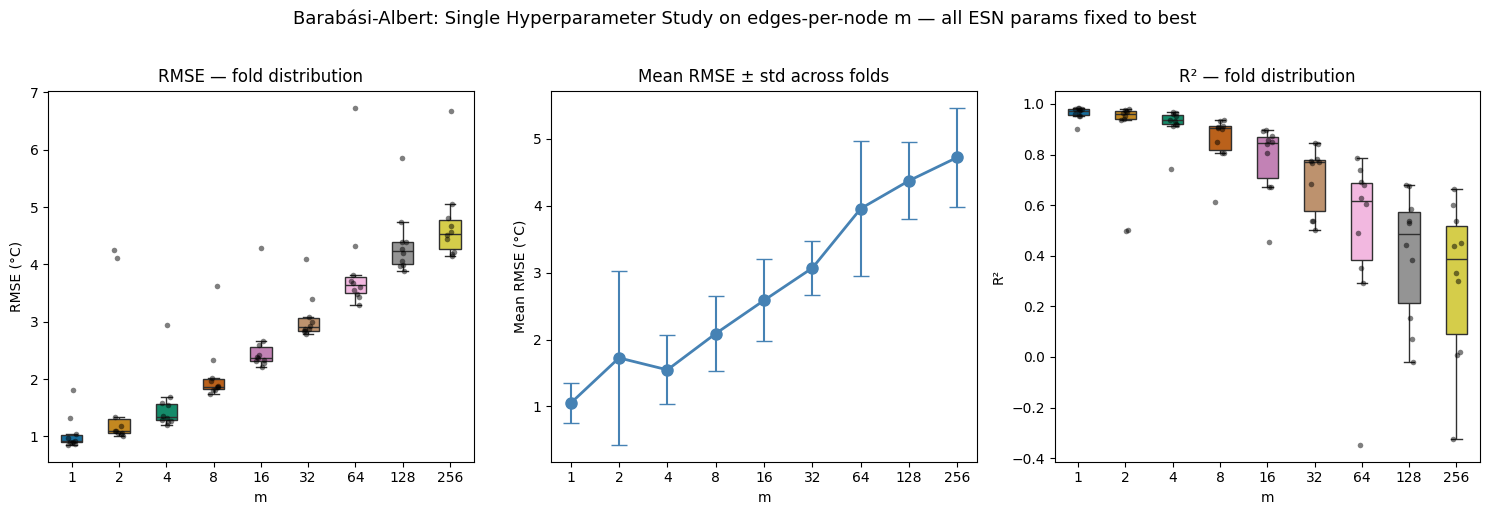


m Single Hyperparameter summary:
     RMSE_mean  RMSE_std  R2_mean  R2_std
m                                        
1       1.0483    0.2993   0.9642  0.0246
2       1.7252    1.3011   0.8692  0.1950
4       1.5465    0.5180   0.9211  0.0660
8       2.0893    0.5619   0.8572  0.0990
16      2.5863    0.6147   0.7817  0.1414
32      3.0710    0.4008   0.7045  0.1307
64      3.9593    1.0129   0.4915  0.3366
128     4.3767    0.5782   0.4043  0.2516
256     4.7263    0.7419   0.3036  0.3120


In [31]:
# ---------------------------------------------------------------------------
# 6.3 Barabási-Albert — Single Hyperparameter Study on edges per new node  m
# ---------------------------------------------------------------------------
ba_m_values = []
m_val = 1
while m_val < best_params["N"]:
    ba_m_values.append(m_val)
    m_val *= 2
ba_m_labels = {v: str(v) for v in ba_m_values}

df_shs_ba_m = run_topology_shs(
    topology="scale_free", param_name="m", param_values=ba_m_values,
    esn_params=best_params)

plot_single_hp(df_shs_ba_m, "m", ba_m_values, label_map=ba_m_labels,
              title="Barabási-Albert: Single Hyperparameter Study on edges-per-node m "
                    "— all ESN params fixed to best")

#### 6.3. Barabási-Albert (Scale-free) — Sensitivity to m

- **Non-monotonic (U-shaped) sensitivity.** RMSE is low at both extremes — m=1 (~1.0 °C) and m=499 (~1.1 °C) — and peaks catastrophically around m=250 (~4.6 °C). The worst range is m=64–350.
- **Best setting: m = 1** (tree-like, minimal density). With only one edge per new node the graph is nearly acyclic and extremely sparse, keeping the natural spectral radius low and dynamics stable.
- **m=499 (near-fully connected) also works well** (~1.1 °C). At maximum density, the weight matrix W approaches a dense Gaussian random matrix whose spectral properties are governed by the Wigner semicircle law, producing a well-behaved and reproducible spectral radius. This is a distinct stable regime from m=1.
- **The intermediate range (m=8–350) is worst** because it combines enough density to raise the spectral radius above 1 (losing the echo state property) while not being dense enough to enter the stable dense-matrix regime. This is the "danger zone" for this topology and normalisation scheme.
- **Hub structure is irrelevant**: the performance is driven entirely by density, not by the preferential attachment mechanism or the degree heterogeneity that defines scale-free graphs.
- **Verdict: STRONG but non-monotonic sensitivity. Avoid intermediate m. Best: m = 1.**

Best ER   : p=1e-06
Best WS   : k=2, p_rewire=0.0
Best BA   : m=1


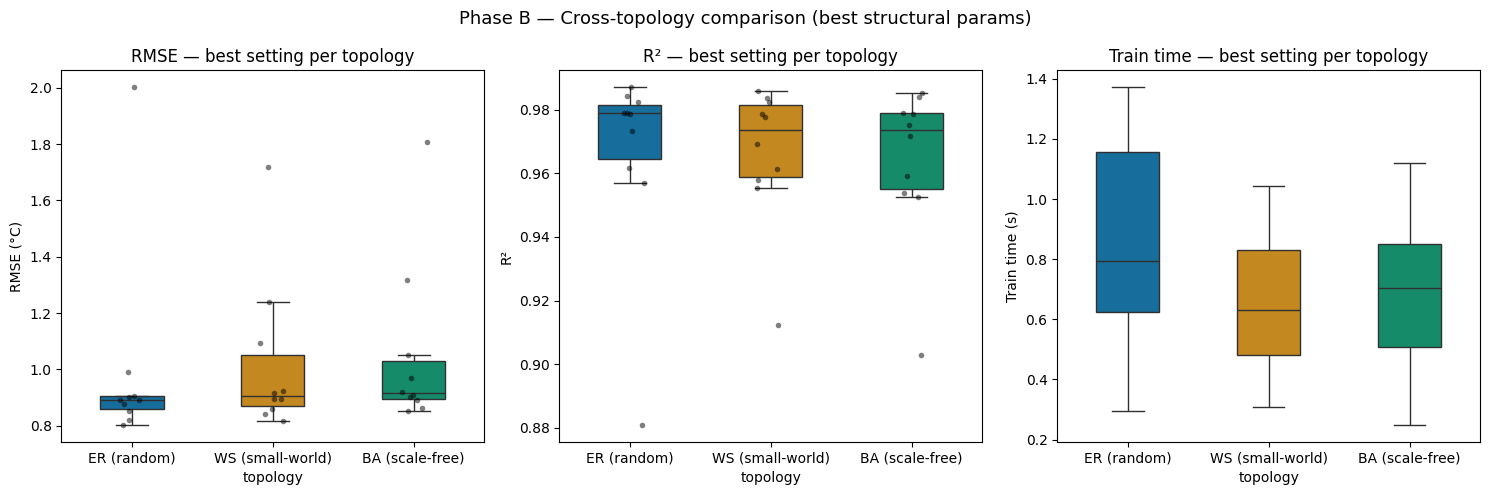


Cross-topology summary (best structural setting each):
                  RMSE_mean  RMSE_std  R2_mean  R2_std  Time_mean  Time_std
topology                                                                   
ER (random)          0.9935    0.3580   0.9663  0.0315     0.8475    0.3528
WS (small-world)     1.0195    0.2772   0.9664  0.0220     0.6532    0.2473
BA (scale-free)      1.0483    0.2993   0.9642  0.0246     0.6915    0.2903


In [32]:
# ---------------------------------------------------------------------------
# 6.4 Cross-topology comparison — best structural setting per topology
# ---------------------------------------------------------------------------

# Identify best p / (k, p_rewire) / m from the corresponding studies.
def best_setting(df, param_name):
    return df.groupby(param_name)["rmse"].mean().idxmin()

best_er_p = best_setting(df_shs_er_p, "p")
best_ba_m = best_setting(df_shs_ba_m, "m")

print(f"Best ER   : p={best_er_p}")
print(f"Best WS   : k={best_ws_k}, p_rewire={best_ws_prw}")
print(f"Best BA   : m={best_ba_m}")

# Extract fold-level results for each best setting and label by topology
def extract_best(df, param_name, best_val, label):
    sub = df[df[param_name] == best_val][["fold", "rmse", "r2", "mae", "train_time_s"]].copy()
    sub["topology"] = label
    return sub

def extract_best_ws(df, best_k, best_prw, label):
    sub = df[(df["k"] == best_k) & (df["p_rewire"] == best_prw)][["fold", "rmse", "r2", "mae", "train_time_s"]].copy()
    sub["topology"] = label
    return sub

df_cross = pd.concat([
    extract_best(df_shs_er_p, "p", best_er_p, "ER (random)"),
    extract_best_ws(df_ws_grid, best_ws_k, best_ws_prw, "WS (small-world)"),
    extract_best(df_shs_ba_m, "m", best_ba_m, "BA (scale-free)"),
], ignore_index=True)

topo_order = ["ER (random)", "WS (small-world)", "BA (scale-free)"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(data=df_cross, x="topology", y="rmse", hue="topology", order=topo_order,
            palette="colorblind", width=0.45, fliersize=0, legend=False, ax=axes[0])
sns.stripplot(data=df_cross, x="topology", y="rmse", order=topo_order,
              color="black", size=4, alpha=0.5, jitter=True, ax=axes[0])
axes[0].set_title("RMSE — best setting per topology")
axes[0].set_ylabel("RMSE (°C)")

sns.boxplot(data=df_cross, x="topology", y="r2", hue="topology", order=topo_order,
            palette="colorblind", width=0.45, fliersize=0, legend=False, ax=axes[1])
sns.stripplot(data=df_cross, x="topology", y="r2", order=topo_order,
              color="black", size=4, alpha=0.5, jitter=True, ax=axes[1])
axes[1].set_title("R² — best setting per topology")
axes[1].set_ylabel("R²")

sns.boxplot(data=df_cross, x="topology", y="train_time_s", hue="topology", order=topo_order,
            palette="colorblind", width=0.45, fliersize=0, legend=False, ax=axes[2])
axes[2].set_title("Train time — best setting per topology")
axes[2].set_ylabel("Train time (s)")

plt.suptitle("Phase B — Cross-topology comparison (best structural params)", fontsize=13)
plt.tight_layout()
plt.show()

# Statistical summary
summary = df_cross.groupby("topology")[["rmse", "r2", "train_time_s"]].agg(["mean", "std"])
summary.columns = ["RMSE_mean", "RMSE_std", "R2_mean", "R2_std", "Time_mean", "Time_std"]
summary = summary.reindex(topo_order)
print()
print("Cross-topology summary (best structural setting each):")
print(summary.round(4).to_string())


### 6.4. Phase B — Overall Conclusions

**Cross-topology comparison (best structural setting per topology)**

| Topology | Best setting | How it is selected |
|---|---|---|
| **ER (random)** | `p = argmin` over sweep | 1D sweep on `p` |
| **WS (small-world)** | `(k, p_rewire) = argmin` over heatmap | joint 2D grid on `k × p_rewire` |
| **BA (scale-free)** | `m = argmin` over sweep | 1D sweep on `m` |

- The WS entry is now selected from the full 2D heatmap, so the earlier fixed-`k` selection artefact is removed.
- This makes the cross-topology comparison cleaner: each topology now contributes its true best structural setting under the evaluation protocol used in Phase B.
- After rerunning the notebook, the ranking should be read from the updated `df_cross` summary rather than from the older fixed-`k` interpretation.


## 7. Conclusions

### 7.1. Forecasting performance

An Echo State Network achieves **mean RMSE ≈ 1.0 °C and R² ≈ 0.97** on 9 of 10 temporal folds for 1-hour ahead 2 m temperature forecasting from ERA5 reanalysis data over Seville. The remaining fold — the earliest, smallest training split — consistently produces RMSE ~5–7 °C regardless of any configuration, revealing a hard temporal non-stationarity boundary that no hyperparameter tuning or topology choice can overcome.

### 7.2. Phase A — Hyperparameter sensitivity

The Single Hyperparameter Study (OAT) across all five hyperparameters yields a clear sensitivity ranking:

| Rank | Parameter | Key finding |
|------|-----------|-------------|
| 1 | **lr** | Hard threshold: lr < 0.01 catastrophic (reservoir state frozen); lr ∈ [0.1, 1.3] flat and safe. The only parameter requiring real care. |
| 2 | **N** | Non-monotonic: rapid gain up to N≈400–500; N>500 degrades (readout overfits). Optimum N≈400–500. |
| 3 | **sr** | Flat zone [0.01, 0.7]; degenerate near 0; chaotic above 1.5. Stay below 1.0 — the "sr > 1 is beneficial" heuristic does not apply. |
| 4 | **ridge** | Near-flat across [1e-6, 1.0]; numerical instability below 1e-30; over-shrinkage above 100. |
| 5 | **washout** | Flat from 0 to 1000; degrades only at washout=5000 (data starvation). True nuisance parameter. |

**Key meta-finding**: only the leak rate requires deliberate tuning. The ESN is robust to all other hyperparameters within wide ranges. The ESN is a purely **autoregressive model** — it predicts $T_{t+1}$ from the 10 most recent temperature values $[T_{t-9}, \ldots, T_t]$; the reservoir adds implicit temporal memory on top of this explicit lag window.

### 7.3. Phase B — Topology sensitivity

The structural Single Hyperparameter Study across Erdős-Rényi, Watts-Strogatz, and Barabási-Albert topologies — without spectral radius rescaling — reveals that **density is the dominant factor**, not topology:

| Parameter | Direction | Key finding |
|---|---|---|
| ER **p** (density) | Higher → worse | Monotonic: p≈0.001 best (~1.1°C), p=1.0 worst (~5.9°C) |
| WS **k** (ring degree) | Higher → worse | Monotonic: k=2 best (~1.1°C), k=499 worst (~5.6°C) |
| WS **p_rewire** | Flat | Negligible effect at any k; small-world regime confers no advantage |
| BA **m** (attachment) | U-shaped | m=1 best (~1.0°C) and m=499 also good (~1.1°C); intermediate m catastrophic |

- **Sparsity is the universal principle**: all three topologies perform best at minimal density. The specific wiring pattern (random, ring-based, hub-based) is secondary.
- **The small-world hypothesis is not confirmed**: the ring-to-random rewiring transition produces no measurable effect on forecasting performance.
- **BA reveals a secondary stable regime**: near-full connectivity (m≈499) also works, likely because the dense random matrix has well-behaved spectral properties by the Wigner semicircle law.
- **Cross-topology ranking** should now be read from the updated joint `(k, p_rewire)` heatmap selection used in Phase B; the earlier fixed-`k` selection artefact is no longer part of the workflow.
- **Practical recommendation**: use a sparse ER reservoir (p≈0.001–0.01) — it is the simplest topology, best understood theoretically, and matches or beats all alternatives at equivalent density.